# Semana 3 — Exploración inicial del dataset OULAD enriquecido

En esta etapa se realiza una exploración inicial de las principales tablas del dataset OULAD con el propósito de comprender la estructura de la información disponible, identificar las relaciones entre tablas y reconocer las variables que posteriormente serán utilizadas para construir un conjunto de datos enriquecido.

A diferencia del análisis inicial basado únicamente en la tabla studentInfo, en esta versión se incorporan datos demográficos, académicos y de interacción dentro del entorno virtual de aprendizaje, permitiendo una visión más completa del comportamiento estudiantil.

Las tablas seleccionadas corresponden a:

- studentInfo.csv
- studentAssessment.csv
- assessments.csv
- studentVle.csv

El análisis exploratorio permitirá verificar la calidad de los datos, identificar valores faltantes y comprender las claves necesarias para integrar la información en etapas posteriores.

## Importación de librerías

In [1]:
# Librerías principales

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


## Carga de los datasets

In [2]:
# Cargar tablas principales de OULAD

student_info = pd.read_csv('../data/studentInfo.csv')

student_assessment = pd.read_csv('../data/studentAssessment.csv')

assessments = pd.read_csv('../data/assessments.csv')

student_vle = pd.read_csv('../data/studentVle.csv')

print("Datasets cargados correctamente")

Datasets cargados correctamente


## Dimensiones de las tablas

In [3]:
datasets = {
    'studentInfo': student_info,
    'studentAssessment': student_assessment,
    'assessments': assessments,
    'studentVle': student_vle
}

for nombre, df in datasets.items():
    print(f'\n{nombre}')
    print(df.shape)


studentInfo
(32593, 12)

studentAssessment
(173912, 5)

assessments
(206, 6)

studentVle
(10655280, 6)


Las dimensiones permiten conocer la cantidad de registros y variables disponibles en cada tabla. Se observa que studentVle contiene una gran cantidad de registros debido a que almacena las interacciones realizadas por los estudiantes dentro del entorno virtual de aprendizaje.

## Visualización inicial de las tablas

In [4]:
student_info.head()

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass


In [5]:
student_assessment.head()

,id_assessment,id_student,date_submitted,is_banked,score
0,1752,11391,18,0,78.0
1,1752,28400,22,0,70.0
2,1752,31604,17,0,72.0
3,1752,32885,26,0,69.0
4,1752,38053,19,0,79.0


In [6]:
assessments.head()

,code_module,code_presentation,id_assessment,assessment_type,date,weight
0,AAA,2013J,1752,TMA,19.0,10.0
1,AAA,2013J,1753,TMA,54.0,20.0
2,AAA,2013J,1754,TMA,117.0,20.0
3,AAA,2013J,1755,TMA,166.0,20.0
4,AAA,2013J,1756,TMA,215.0,30.0


In [7]:
student_vle.head()

,code_module,code_presentation,id_student,id_site,date,sum_click
0,AAA,2013J,28400,546652,-10,4
1,AAA,2013J,28400,546652,-10,1
2,AAA,2013J,28400,546652,-10,1
3,AAA,2013J,28400,546614,-10,11
4,AAA,2013J,28400,546714,-10,1


La visualización inicial permite identificar las variables presentes en cada tabla y comprender el tipo de información que aportan al proceso de análisis.

## Tipos de datos

In [8]:
for nombre, df in datasets.items():

    print("\n" + "="*50)
    print(nombre)
    print("="*50)

    print(df.info())


studentInfo
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   code_module           32593 non-null  object
 1   code_presentation     32593 non-null  object
 2   id_student            32593 non-null  int64 
 3   gender                32593 non-null  object
 4   region                32593 non-null  object
 5   highest_education     32593 non-null  object
 6   imd_band              31482 non-null  object
 7   age_band              32593 non-null  object
 8   num_of_prev_attempts  32593 non-null  int64 
 9   studied_credits       32593 non-null  int64 
 10  disability            32593 non-null  object
 11  final_result          32593 non-null  object
dtypes: int64(3), object(9)
memory usage: 3.0+ MB
None

studentAssessment
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 173912 entries, 0 to 173911
Data columns (total 5 colu

## Variables disponibles

In [9]:
for nombre, df in datasets.items():

    print(f'\n{nombre}')

    print(df.columns.tolist())


studentInfo
['code_module', 'code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result']

studentAssessment
['id_assessment', 'id_student', 'date_submitted', 'is_banked', 'score']

assessments
['code_module', 'code_presentation', 'id_assessment', 'assessment_type', 'date', 'weight']

studentVle
['code_module', 'code_presentation', 'id_student', 'id_site', 'date', 'sum_click']


Las variables disponibles muestran que cada tabla aporta información complementaria. Mientras studentInfo contiene características demográficas y académicas generales, studentAssessment registra resultados de evaluaciones, assessments almacena información sobre las actividades evaluativas y studentVle contiene los registros de interacción dentro de la plataforma virtual.

## Verificación de valores faltantes

In [10]:
for nombre, df in datasets.items():

    print(f'\n{nombre}')

    print(df.isnull().sum())


studentInfo
code_module                0
code_presentation          0
id_student                 0
gender                     0
region                     0
highest_education          0
imd_band                1111
age_band                   0
num_of_prev_attempts       0
studied_credits            0
disability                 0
final_result               0
dtype: int64

studentAssessment
id_assessment       0
id_student          0
date_submitted      0
is_banked           0
score             173
dtype: int64

assessments
code_module           0
code_presentation     0
id_assessment         0
assessment_type       0
date                 11
weight                0
dtype: int64

studentVle
code_module          0
code_presentation    0
id_student           0
id_site              0
date                 0
sum_click            0
dtype: int64


La identificación temprana de valores faltantes permite planificar las estrategias de limpieza y tratamiento que serán aplicadas en etapas posteriores.

## Identificación de claves de integración

In [11]:
print("studentInfo")
print(student_info[['id_student',
                    'code_module',
                    'code_presentation']].head())

print("\nstudentAssessment")
print(student_assessment[['id_student',
                          'id_assessment']].head())

print("\nassessments")
print(assessments[['id_assessment',
                   'code_module',
                   'code_presentation']].head())

print("\nstudentVle")
print(student_vle[['id_student',
                   'code_module',
                   'code_presentation']].head())

studentInfo
   id_student code_module code_presentation
0       11391         AAA             2013J
1       28400         AAA             2013J
2       30268         AAA             2013J
3       31604         AAA             2013J
4       32885         AAA             2013J

studentAssessment
   id_student  id_assessment
0       11391           1752
1       28400           1752
2       31604           1752
3       32885           1752
4       38053           1752

assessments
   id_assessment code_module code_presentation
0           1752         AAA             2013J
1           1753         AAA             2013J
2           1754         AAA             2013J
3           1755         AAA             2013J
4           1756         AAA             2013J

studentVle
   id_student code_module code_presentation
0       28400         AAA             2013J
1       28400         AAA             2013J
2       28400         AAA             2013J
3       28400         AAA             2013J
4   

Se observa que las variables id_student, code_module y code_presentation constituyen las principales claves para integrar la información proveniente de las diferentes tablas. Asimismo, id_assessment permite vincular los resultados obtenidos por cada estudiante con las características específicas de cada evaluación.

## Estadísticas descriptivas

In [12]:
student_info.describe(include='all')

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
count,32593,32593,3.259300e+04,32593,32593,32593,31482,32593,32593.000000,32593.000000,32593,32593
unique,7,4,NaN,2,13,5,10,3,NaN,NaN,2,4
top,BBB,2014J,NaN,M,Scotland,A Level or Equivalent,20-30%,0-35,NaN,NaN,N,Pass
freq,7909,11260,NaN,17875,3446,14045,3654,22944,NaN,NaN,29429,12361
mean,NaN,NaN,7.066877e+05,NaN,NaN,NaN,NaN,NaN,0.163225,79.758691,NaN,NaN
std,NaN,NaN,5.491673e+05,NaN,NaN,NaN,NaN,NaN,0.479758,41.071900,NaN,NaN
min,NaN,NaN,3.733000e+03,NaN,NaN,NaN,NaN,NaN,0.000000,30.000000,NaN,NaN
25%,NaN,NaN,5.085730e+05,NaN,NaN,NaN,NaN,NaN,0.000000,60.000000,NaN,NaN
50%,NaN,NaN,5.903100e+05,NaN,NaN,NaN,NaN,NaN,0.000000,60.000000,NaN,NaN
75%,NaN,NaN,6.444530e+05,NaN,NaN,NaN,NaN,NaN,0.000000,120.000000,NaN,NaN


In [13]:
student_assessment.describe()

,id_assessment,id_student,date_submitted,is_banked,score
count,173912.000000,1.739120e+05,173912.000000,173912.000000,173739.000000
mean,26553.803556,7.051507e+05,116.032942,0.010977,75.799573
std,8829.784254,5.523952e+05,71.484148,0.104194,18.798107
min,1752.000000,6.516000e+03,-11.000000,0.000000,0.000000
25%,15022.000000,5.044290e+05,51.000000,0.000000,65.000000
50%,25359.000000,5.852080e+05,116.000000,0.000000,80.000000
75%,34883.000000,6.344980e+05,173.000000,0.000000,90.000000
max,37443.000000,2.698588e+06,608.000000,1.000000,100.000000


In [14]:
assessments.describe()

,id_assessment,date,weight
count,206.000000,195.000000,206.000000
mean,26473.975728,145.005128,20.873786
std,10098.625521,76.001119,30.384224
min,1752.000000,12.000000,0.000000
25%,15023.250000,71.000000,0.000000
50%,25364.500000,152.000000,12.500000
75%,34891.750000,222.000000,24.250000
max,40088.000000,261.000000,100.000000


In [15]:
student_vle.describe()

,id_student,id_site,date,sum_click
count,1.065528e+07,1.065528e+07,1.065528e+07,1.065528e+07
mean,7.333336e+05,7.383234e+05,9.517400e+01,3.716946e+00
std,5.827060e+05,1.312196e+05,7.607130e+01,8.849047e+00
min,6.516000e+03,5.267210e+05,-2.500000e+01,1.000000e+00
25%,5.077430e+05,6.735190e+05,2.500000e+01,1.000000e+00
50%,5.882360e+05,7.300690e+05,8.600000e+01,2.000000e+00
75%,6.464840e+05,8.770300e+05,1.560000e+02,3.000000e+00
max,2.698588e+06,1.049562e+06,2.690000e+02,6.977000e+03


# Conclusiones de la Semana 3

Se realizó una exploración inicial de las cuatro tablas principales seleccionadas para la construcción del dataset enriquecido. El análisis permitió identificar la estructura de los datos, las variables disponibles, la presencia de valores faltantes y las claves necesarias para la integración de la información.

Las tablas studentAssessment y studentVle aportan información relacionada con el desempeño académico y el comportamiento de interacción del estudiante, aspectos que la literatura reporta como altamente predictivos del rendimiento académico. Estas fuentes de información serán utilizadas en las siguientes etapas para generar nuevas características y construir un conjunto de datos enriquecido orientado a mejorar el desempeño de los modelos de Machine Learning.

# Semana 4 — Limpieza básica y análisis descriptivo del dataset enriquecido

En esta etapa se realiza una limpieza básica de las tablas seleccionadas del dataset OULAD y un análisis descriptivo de las principales variables que serán utilizadas posteriormente para construir un conjunto de datos enriquecido.

El objetivo es identificar posibles problemas de calidad de datos, analizar la distribución de las variables más relevantes y comprender el comportamiento académico y de interacción de los estudiantes antes de iniciar el proceso de integración de datos y generación de características.

Las tablas analizadas corresponden a:

- studentInfo
- studentAssessment
- assessments
- studentVle

Este análisis permitirá establecer una base sólida para la construcción de variables predictivas en las siguientes etapas del proyecto.

## Creación de copias de trabajo

In [16]:
student_info_clean = student_info.copy()

student_assessment_clean = student_assessment.copy()

assessments_clean = assessments.copy()

student_vle_clean = student_vle.copy()

print("Copias de trabajo creadas correctamente")

Copias de trabajo creadas correctamente


## Verificación de valores faltantes

In [17]:
for nombre, df in {
    'studentInfo': student_info_clean,
    'studentAssessment': student_assessment_clean,
    'assessments': assessments_clean,
    'studentVle': student_vle_clean
}.items():

    print("\n" + "="*50)
    print(nombre)
    print("="*50)

    print(df.isnull().sum())


studentInfo
code_module                0
code_presentation          0
id_student                 0
gender                     0
region                     0
highest_education          0
imd_band                1111
age_band                   0
num_of_prev_attempts       0
studied_credits            0
disability                 0
final_result               0
dtype: int64

studentAssessment
id_assessment       0
id_student          0
date_submitted      0
is_banked           0
score             173
dtype: int64

assessments
code_module           0
code_presentation     0
id_assessment         0
assessment_type       0
date                 11
weight                0
dtype: int64

studentVle
code_module          0
code_presentation    0
id_student           0
id_site              0
date                 0
sum_click            0
dtype: int64


La revisión de valores faltantes permite identificar variables que requerirán tratamiento durante las etapas posteriores de preparación de datos. Particularmente, se presta atención a variables demográficas presentes en studentInfo, ya que pueden afectar el desempeño de los modelos predictivos.

# Análisis de studentInfo

## Distribución de género

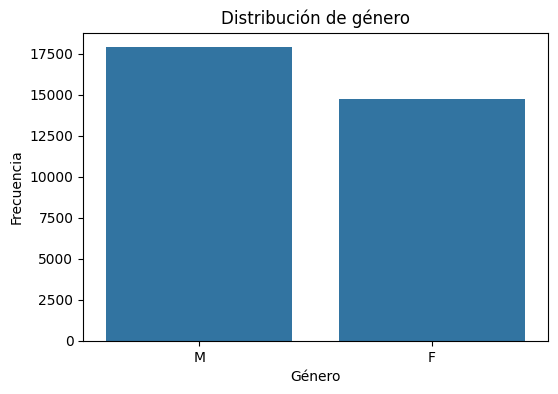

In [18]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=student_info_clean,
    x='gender'
)

plt.title('Distribución de género')
plt.xlabel('Género')
plt.ylabel('Frecuencia')

plt.show()

## Nivel educativo

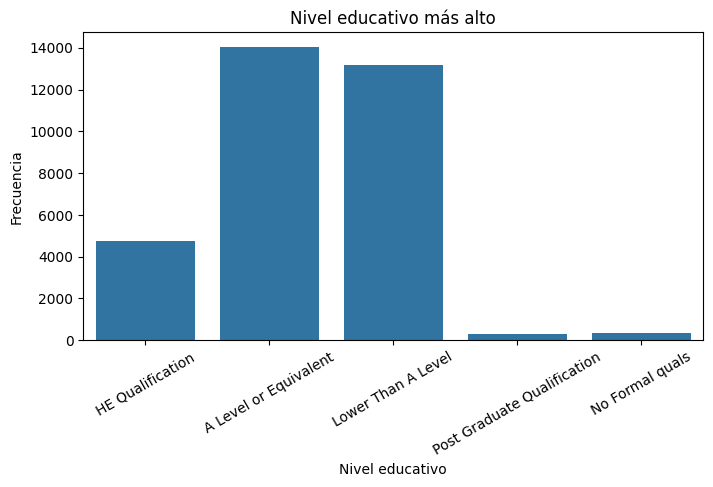

In [19]:
plt.figure(figsize=(8,4))

sns.countplot(
    data=student_info_clean,
    x='highest_education'
)

plt.xticks(rotation=30)

plt.title('Nivel educativo más alto')
plt.xlabel('Nivel educativo')
plt.ylabel('Frecuencia')

plt.show()

## Intentos previos

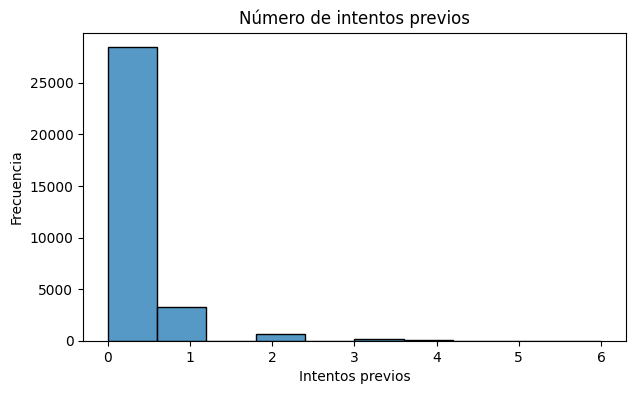

In [20]:
plt.figure(figsize=(7,4))

sns.histplot(
    student_info_clean['num_of_prev_attempts'],
    bins=10
)

plt.title('Número de intentos previos')
plt.xlabel('Intentos previos')
plt.ylabel('Frecuencia')

plt.show()

## Créditos estudiados

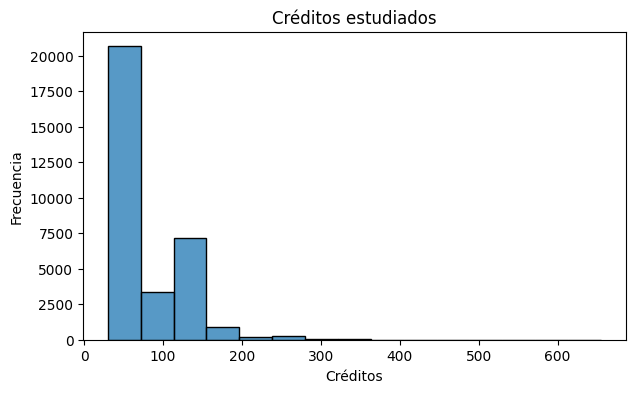

In [21]:
plt.figure(figsize=(7,4))

sns.histplot(
    student_info_clean['studied_credits'],
    bins=15
)

plt.title('Créditos estudiados')
plt.xlabel('Créditos')
plt.ylabel('Frecuencia')

plt.show()

# Análisis de studentAssessment

## Distribución de calificaciones obtenidas

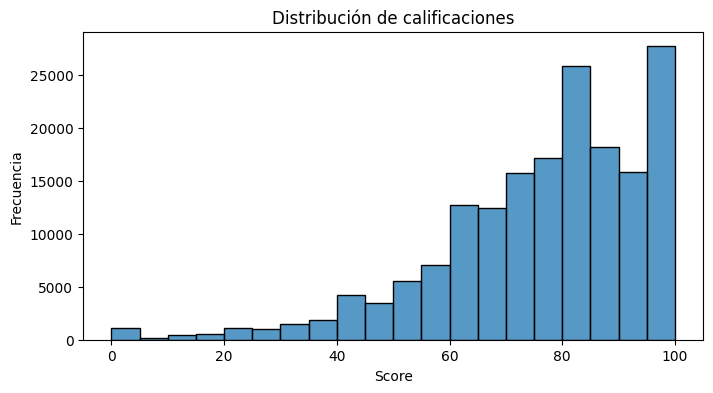

In [22]:
plt.figure(figsize=(8,4))

sns.histplot(
    student_assessment_clean['score'],
    bins=20
)

plt.title('Distribución de calificaciones')
plt.xlabel('Score')
plt.ylabel('Frecuencia')

plt.show()

In [23]:
student_assessment_clean['score'].describe()

count    173739.000000
mean         75.799573
std          18.798107
min           0.000000
25%          65.000000
50%          80.000000
75%          90.000000
max         100.000000
Name: score, dtype: float64

La variable score representa la calificación obtenida por cada estudiante en una evaluación específica. Su distribución permite identificar el comportamiento general del rendimiento académico dentro del conjunto de datos.

# Análisis de assessments

## Distribución de tipos de evaluación

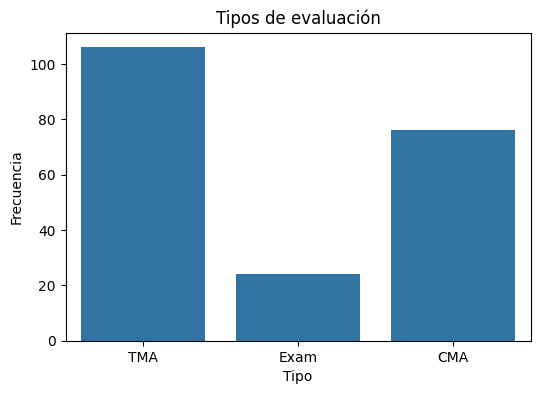

In [24]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=assessments_clean,
    x='assessment_type'
)

plt.title('Tipos de evaluación')
plt.xlabel('Tipo')
plt.ylabel('Frecuencia')

plt.show()

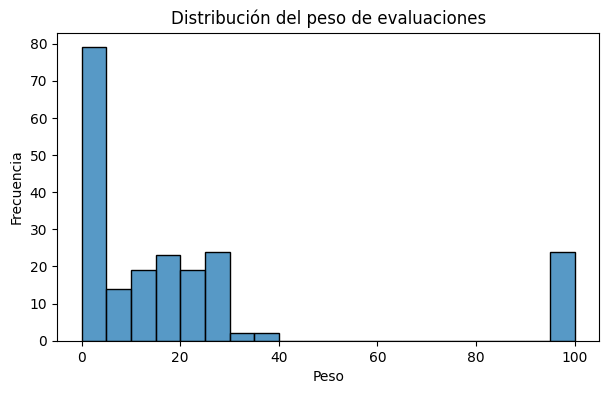

In [25]:
plt.figure(figsize=(7,4))

sns.histplot(
    assessments_clean['weight'],
    bins=20
)

plt.title('Distribución del peso de evaluaciones')
plt.xlabel('Peso')
plt.ylabel('Frecuencia')

plt.show()

La variable weight representa la importancia relativa de cada evaluación dentro del módulo académico. Esta información será utilizada posteriormente para calcular indicadores de rendimiento ponderado.

# Análisis de studentVle

## Distribución de interacciones en el entorno virtual

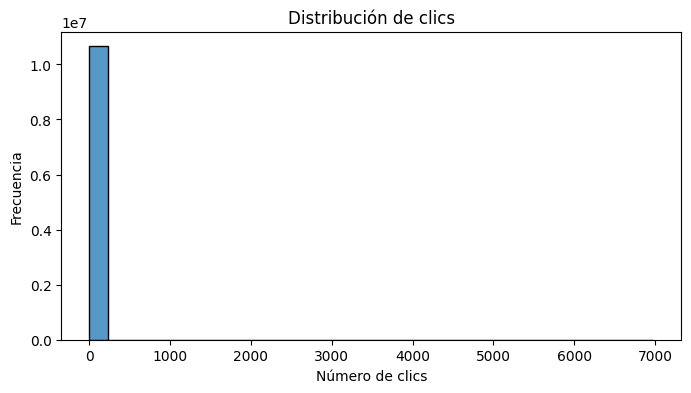

In [26]:
plt.figure(figsize=(8,4))

sns.histplot(
    student_vle_clean['sum_click'],
    bins=30
)

plt.title('Distribución de clics')
plt.xlabel('Número de clics')
plt.ylabel('Frecuencia')

plt.show()

In [27]:
student_vle_clean['sum_click'].describe()

count    1.065528e+07
mean     3.716946e+00
std      8.849047e+00
min      1.000000e+00
25%      1.000000e+00
50%      2.000000e+00
75%      3.000000e+00
max      6.977000e+03
Name: sum_click, dtype: float64

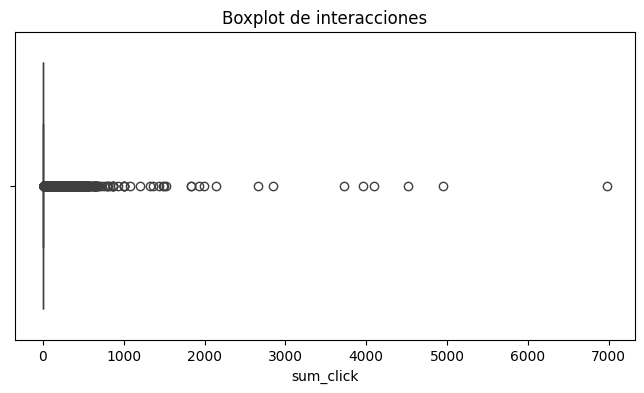

In [28]:
plt.figure(figsize=(8,4))

sns.boxplot(
    x=student_vle_clean['sum_click']
)

plt.title('Boxplot de interacciones')

plt.show()

La variable sum_click registra la cantidad de interacciones realizadas por los estudiantes dentro del entorno virtual de aprendizaje. La literatura especializada reporta esta variable como uno de los predictores más importantes del rendimiento académico, debido a que refleja el nivel de participación y compromiso del estudiante con el curso.

## Variables con potencial predictivo

A partir del análisis descriptivo realizado, se identifican variables que podrían aportar información relevante para la predicción del rendimiento académico:

- score
- weight
- sum_click
- studied_credits
- num_of_prev_attempts

Estas variables serán utilizadas posteriormente para construir nuevas características derivadas mediante procesos de agregación e integración de datos.

# Conclusiones de la Semana 4

Se realizó una limpieza básica y un análisis descriptivo de las principales tablas seleccionadas del dataset OULAD. El análisis permitió comprender la distribución de variables demográficas, académicas y de interacción dentro del entorno virtual.

Los resultados muestran que las tablas studentAssessment y studentVle contienen información potencialmente más relacionada con el rendimiento académico que las variables demográficas tradicionales. Particularmente, las calificaciones obtenidas en evaluaciones y el número de interacciones registradas en la plataforma virtual aparecen como candidatos importantes para la generación de características predictivas.

Con esta etapa finalizada, el proyecto queda preparado para la siguiente fase, correspondiente a la integración de tablas y construcción de variables derivadas que conformarán el dataset enriquecido utilizado para el entrenamiento de modelos de Machine Learning.

In [29]:
print(student_assessment.columns.tolist())

['id_assessment', 'id_student', 'date_submitted', 'is_banked', 'score']


# Semana 5 — Integración de datos e ingeniería de características del dataset enriquecido

En esta etapa se realiza la integración de las principales tablas seleccionadas del dataset OULAD con el objetivo de construir un conjunto de datos enriquecido orientado a la predicción del rendimiento académico.

La literatura reciente sobre Learning Analytics y Educational Data Mining ha demostrado que las variables derivadas de evaluaciones académicas e interacciones dentro del entorno virtual poseen una capacidad predictiva superior a las variables demográficas tradicionales. Por esta razón, durante esta fase se generan nuevas características que resumen el comportamiento académico y el nivel de participación de los estudiantes.

Las tablas utilizadas corresponden a:

studentInfo
studentAssessment
assessments
studentVle

El resultado de esta etapa será un dataset enriquecido listo para ser utilizado en el entrenamiento de modelos de Machine Learning en las siguientes semanas.

# 5.1 Preparación de las tablas de trabajo

In [30]:
student_info = student_info_clean.copy()

student_assessment = student_assessment_clean.copy()

assessments = assessments_clean.copy()

student_vle = student_vle_clean.copy()

print("Tablas preparadas correctamente")

Tablas preparadas correctamente


# 5.2 Construcción de la base académica

In [31]:
assessment_data = pd.merge(
    student_assessment,
    assessments,
    on='id_assessment',
    how='left'
)

assessment_data.head()

,id_assessment,id_student,date_submitted,is_banked,score,code_module,code_presentation,assessment_type,date,weight
0,1752,11391,18,0,78.0,AAA,2013J,TMA,19.0,10.0
1,1752,28400,22,0,70.0,AAA,2013J,TMA,19.0,10.0
2,1752,31604,17,0,72.0,AAA,2013J,TMA,19.0,10.0
3,1752,32885,26,0,69.0,AAA,2013J,TMA,19.0,10.0
4,1752,38053,19,0,79.0,AAA,2013J,TMA,19.0,10.0


## Verificación de dimensiones


In [32]:
assessment_data.shape

(173912, 10)

## Verificación de valores faltantes

In [33]:
assessment_data.isnull().sum()

id_assessment           0
id_student              0
date_submitted          0
is_banked               0
score                 173
code_module             0
code_presentation       0
assessment_type         0
date                 2865
weight                  0
dtype: int64

# 5.3 Generación de variables académicas
Construir indicadores que representen el desempeño académico global del estudiante.

## Claves de agrupación

In [34]:
group_cols = [
    'id_student',
    'code_module',
    'code_presentation'
]

## Score promedio

In [35]:
score_mean = (
    assessment_data
    .groupby(group_cols)['score']
    .mean()
    .reset_index()
    .rename(columns={'score':'score_mean'})
)

## Score máximo

In [36]:
score_max = (
    assessment_data
    .groupby(group_cols)['score']
    .max()
    .reset_index()
    .rename(columns={'score':'score_max'})
)

## Score mínimo

In [37]:
score_min = (
    assessment_data
    .groupby(group_cols)['score']
    .min()
    .reset_index()
    .rename(columns={'score':'score_min'})
)

## Desviación estándar de scores

In [38]:
score_std = (
    assessment_data
    .groupby(group_cols)['score']
    .std()
    .reset_index()
    .rename(columns={'score':'score_std'})
)

## Número de evaluaciones realizadas

In [39]:
num_assessments = (
    assessment_data
    .groupby(group_cols)
    .size()
    .reset_index(name='num_assessments')
)

# 5.4 Cálculo de weighted_grade
Incorporar el peso académico de cada evaluación.

In [40]:
assessment_data['weighted_score'] = (
    assessment_data['score']
    *
    assessment_data['weight']
) / 100

In [41]:
weighted_grade = (
    assessment_data
    .groupby(group_cols)['weighted_score']
    .sum()
    .reset_index()
    .rename(columns={
        'weighted_score':'weighted_grade'
    })
)

# 5.5 Construcción de score_trend
Analizar la evolución temporal del rendimiento académico.

In [42]:
from scipy.stats import linregress
import numpy as np

In [43]:
def calculate_trend(group):

    group = group.sort_values(
        'date_submitted'
    )

    # Menos de 2 registros
    if len(group) < 2:
        return 0

    # Todas las fechas iguales
    if group['date_submitted'].nunique() < 2:
        return 0

    try:

        slope, _, _, _, _ = linregress(
            group['date_submitted'],
            group['score']
        )

        return slope

    except:
        return 0

In [44]:
score_trend = (
    assessment_data
    .groupby(group_cols)
    .apply(calculate_trend)
    .reset_index(name='score_trend')
)

C:\Users\Usuario\AppData\Local\Temp\ipykernel_23456\3356217794.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(calculate_trend)


# 5.6 Indicadores de procrastinación
Identificar comportamientos relacionados con retrasos en las entregas.

## Retraso de entrega

In [45]:
assessment_data['submission_delay'] = (
    assessment_data['date_submitted']
    -
    assessment_data['date']
)

## Entregas tardías

In [46]:
assessment_data['late_submission'] = (
    assessment_data['submission_delay'] > 0
).astype(int)

## Ratio de entregas tardías

In [47]:
late_submission_ratio = (
    assessment_data
    .groupby(group_cols)['late_submission']
    .mean()
    .reset_index()
    .rename(columns={
        'late_submission':
        'late_submission_ratio'
    })
)

# 5.7 Actividades no completadas
Detectar evaluaciones entregadas con puntaje cero.

In [48]:
assessment_data['unfinished'] = (
    assessment_data['score'] == 0
).astype(int)

In [49]:
unfinished_tasks = (
    assessment_data
    .groupby(group_cols)['unfinished']
    .sum()
    .reset_index()
    .rename(columns={
        'unfinished':
        'unfinished_tasks'
    })
)

# 5.8 Construcción de variables de interacción
Generar indicadores de compromiso dentro del entorno virtual de aprendizaje.

## Total de clics

In [50]:
total_clicks = (
    student_vle
    .groupby(group_cols)['sum_click']
    .sum()
    .reset_index()
    .rename(columns={
        'sum_click':'total_clicks'
    })
)

## Días activos

In [51]:
active_days = (
    student_vle
    .groupby(group_cols)['date']
    .nunique()
    .reset_index()
    .rename(columns={
        'date':'active_days'
    })
)

## Máximo de clics por día

In [52]:
max_clicks_day = (
    student_vle
    .groupby(group_cols)['sum_click']
    .max()
    .reset_index()
    .rename(columns={
        'sum_click':'max_clicks_day'
    })
)

## Mediana de clics por día


In [53]:
median_clicks_day = (
    student_vle
    .groupby(group_cols)['sum_click']
    .median()
    .reset_index()
    .rename(columns={
        'sum_click':'median_clicks_day'
    })
)

## Integración de variables de interacción

In [54]:
engagement = total_clicks.merge(
    active_days,
    on=group_cols
)

engagement = engagement.merge(
    max_clicks_day,
    on=group_cols
)

engagement = engagement.merge(
    median_clicks_day,
    on=group_cols
)

In [55]:
engagement['avg_clicks_per_day'] = (
    engagement['total_clicks']
    /
    engagement['active_days']
)

# 5.9 Construcción del dataset enriquecido
Integrar todas las variables derivadas en una única tabla.

## Dataset base

In [56]:
dataset_final = student_info.copy()

## Lista de variables derivadas

In [57]:
features = [
    score_mean,
    score_max,
    score_min,
    score_std,
    num_assessments,
    weighted_grade,
    score_trend,
    late_submission_ratio,
    unfinished_tasks,
    engagement
]

## Integración

In [58]:
for feature in features:

    dataset_final = dataset_final.merge(
        feature,
        on=group_cols,
        how='left'
    )

# 5.10 Tratamiento de valores faltantes
Garantizar la integridad del dataset final.

In [59]:
numeric_cols = dataset_final.select_dtypes(
    include=np.number
).columns

In [60]:
for col in numeric_cols:

    dataset_final[col] = (
        dataset_final[col]
        .fillna(
            dataset_final[col].median()
        )
    )

# 5.11 Eliminación de registros duplicados

In [61]:
dataset_final = (
    dataset_final
    .drop_duplicates()
)

# 5.12 Análisis descriptivo de las variables derivadas

## Estadísticas descriptivas

In [62]:
dataset_final[
    [
        'score_mean',
        'weighted_grade',
        'total_clicks',
        'active_days',
        'avg_clicks_per_day'
    ]
].describe()

,score_mean,weighted_grade,total_clicks,active_days,avg_clicks_per_day
count,32593.000000,32593.000000,32593.000000,32593.000000,32593.000000
mean,73.439828,61.653769,1291.489476,60.328107,18.765371
std,14.633427,42.614443,1652.267653,51.361869,10.993251
min,0.000000,0.000000,1.000000,1.000000,1.000000
25%,68.000000,27.000000,303.000000,21.000000,11.750000
50%,76.000000,63.540000,739.500000,47.000000,16.360556
75%,82.400000,80.750000,1585.000000,85.000000,23.157895
max,100.000000,200.000000,24139.000000,286.000000,221.200000


## Distribución de score_mean

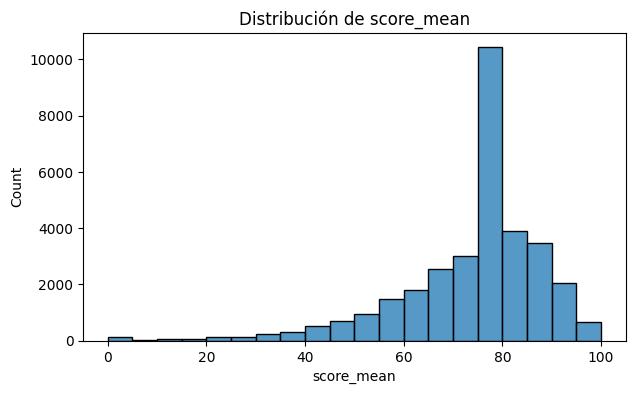

In [63]:
plt.figure(figsize=(7,4))

sns.histplot(
    dataset_final['score_mean'],
    bins=20
)

plt.title(
    'Distribución de score_mean'
)

plt.show()

## Distribución de weighted_grade

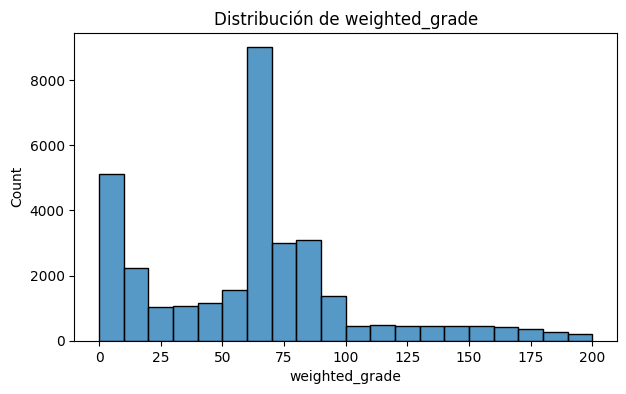

In [64]:
plt.figure(figsize=(7,4))

sns.histplot(
    dataset_final['weighted_grade'],
    bins=20
)

plt.title(
    'Distribución de weighted_grade'
)

plt.show()

## Distribución de total_clicks

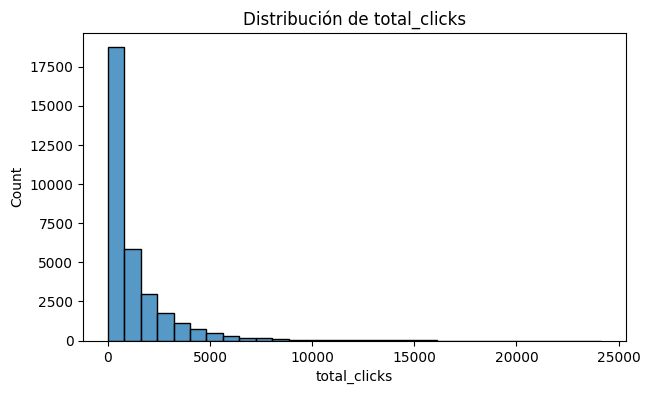

In [65]:
plt.figure(figsize=(7,4))

sns.histplot(
    dataset_final['total_clicks'],
    bins=30
)

plt.title(
    'Distribución de total_clicks'
)

plt.show()

# 5.13 Análisis de correlación
Identificar relaciones entre las variables predictoras.

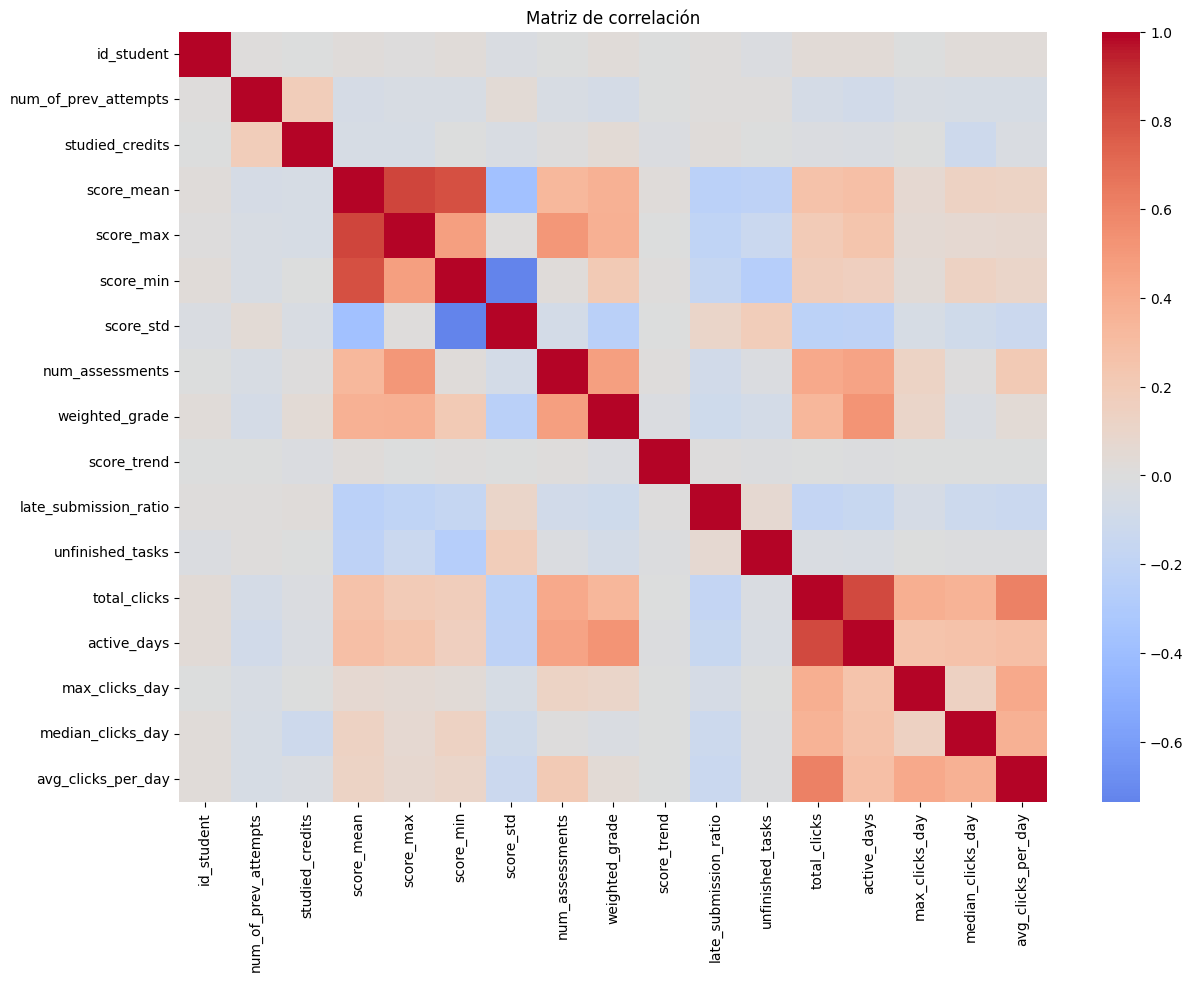

In [66]:
plt.figure(figsize=(14,10))

sns.heatmap(
    dataset_final.corr(
        numeric_only=True
    ),
    cmap='coolwarm',
    center=0
)

plt.title(
    'Matriz de correlación'
)

plt.show()

# 5.14 Verificación final del dataset

In [67]:
dataset_final.shape

(32593, 26)

In [68]:
dataset_final.head()

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,score_mean,score_max,score_min,score_std,num_assessments,weighted_grade,score_trend,late_submission_ratio,unfinished_tasks,total_clicks,active_days,max_clicks_day,median_clicks_day,avg_clicks_per_day
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,82.0,85.0,78.0,3.082207,5.0,82.40,0.013944,0.0,0.0,934.0,40.0,76.0,2.0,23.350000
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,66.4,70.0,60.0,4.335897,5.0,65.40,-0.047112,0.4,0.0,1435.0,80.0,23.0,2.0,17.937500
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,76.0,92.0,60.0,12.020815,7.0,63.54,-0.015819,0.2,0.0,281.0,12.0,23.0,2.0,23.416667
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,76.0,88.0,71.0,6.892024,5.0,76.30,0.047119,0.0,0.0,2158.0,123.0,22.0,2.0,17.544715
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,54.4,75.0,30.0,20.513410,5.0,55.00,0.027281,1.0,0.0,1034.0,70.0,22.0,2.0,14.771429


In [69]:
dataset_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   code_module            32593 non-null  object 
 1   code_presentation      32593 non-null  object 
 2   id_student             32593 non-null  int64  
 3   gender                 32593 non-null  object 
 4   region                 32593 non-null  object 
 5   highest_education      32593 non-null  object 
 6   imd_band               31482 non-null  object 
 7   age_band               32593 non-null  object 
 8   num_of_prev_attempts   32593 non-null  int64  
 9   studied_credits        32593 non-null  int64  
 10  disability             32593 non-null  object 
 11  final_result           32593 non-null  object 
 12  score_mean             32593 non-null  float64
 13  score_max              32593 non-null  float64
 14  score_min              32593 non-null  float64
 15  sc

## Verificación final de valores faltantes

In [70]:
dataset_final.isnull().sum()

code_module                 0
code_presentation           0
id_student                  0
gender                      0
region                      0
highest_education           0
imd_band                 1111
age_band                    0
num_of_prev_attempts        0
studied_credits             0
disability                  0
final_result                0
score_mean                  0
score_max                   0
score_min                   0
score_std                   0
num_assessments             0
weighted_grade              0
score_trend                 0
late_submission_ratio       0
unfinished_tasks            0
total_clicks                0
active_days                 0
max_clicks_day              0
median_clicks_day           0
avg_clicks_per_day          0
dtype: int64

In [71]:
dataset_final['imd_band'].isnull().sum()

np.int64(1111)

In [72]:
dataset_final['imd_band'].value_counts()

imd_band
20-30%     3654
30-40%     3539
10-20      3516
0-10%      3311
40-50%     3256
50-60%     3124
60-70%     2905
70-80%     2879
80-90%     2762
90-100%    2536
Name: count, dtype: int64

In [73]:
dataset_final['imd_band'] = (
    dataset_final['imd_band']
    .fillna(
        dataset_final['imd_band'].mode()[0]
    )
)

In [74]:
dataset_final['imd_band'].isnull().sum()

np.int64(0)

In [75]:
dataset_final.to_csv(
    '../data-enriquecido/dataset_enriched_final.csv',
    index=False
)

print("Dataset enriquecido guardado correctamente")

Dataset enriquecido guardado correctamente


In [76]:
dataset_check = pd.read_csv(
    '../data-enriquecido/dataset_enriched_final.csv'
)

dataset_check.shape

(32593, 26)


# Conclusiones de la Semana 5

Se realizó la integración de las principales tablas del dataset OULAD y se construyó un conjunto de datos enriquecido mediante la generación de variables derivadas académicas y de interacción.

Las nuevas características permiten representar de manera más precisa el comportamiento del estudiante dentro del curso, incorporando indicadores relacionados con rendimiento académico, tendencias de aprendizaje, procrastinación y nivel de participación dentro del entorno virtual.

El dataset resultante queda preparado para la siguiente fase del proyecto, correspondiente al entrenamiento y evaluación de modelos de Machine Learning para la predicción del rendimiento académico.


# Semana 6 — Implementación del modelo baseline con Regresión Logística

## 6.1 Construcción de la variable objetivo binaria

In [77]:
# Crear copia para modelado

df_model = dataset_final.copy()


# Conversión del problema a clasificación binaria

df_model['target'] = (
    df_model['final_result']
    .isin(['Fail','Withdrawn'])
    .astype(int)
)


# Revisar distribución

df_model['target'].value_counts()

target
1    17208
0    15385
Name: count, dtype: int64

## 6.2 Eliminación de variable original target

In [78]:
df_model = df_model.drop(
    'final_result',
    axis=1
)

## 6.3 Separación variables categóricas y numéricas

In [79]:
categorical_cols = df_model.select_dtypes(
    include=['object']
).columns


numeric_cols = df_model.select_dtypes(
    include=['int64','float64']
).columns


print("Variables categóricas:")
print(list(categorical_cols))


print("\nVariables numéricas:")
print(list(numeric_cols))

Variables categóricas:
['code_module', 'code_presentation', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'disability']

Variables numéricas:
['id_student', 'num_of_prev_attempts', 'studied_credits', 'score_mean', 'score_max', 'score_min', 'score_std', 'num_assessments', 'weighted_grade', 'score_trend', 'late_submission_ratio', 'unfinished_tasks', 'total_clicks', 'active_days', 'max_clicks_day', 'median_clicks_day', 'avg_clicks_per_day', 'target']


## 6.4 Codificación de variables categóricas

In [80]:
df_encoded = pd.get_dummies(
    df_model,
    columns=categorical_cols,
    drop_first=True
)


df_encoded.head()

,id_student,num_of_prev_attempts,studied_credits,score_mean,score_max,score_min,score_std,num_assessments,weighted_grade,score_trend,late_submission_ratio,unfinished_tasks,total_clicks,active_days,max_clicks_day,median_clicks_day,avg_clicks_per_day,target,code_module_BBB,code_module_CCC,code_module_DDD,code_module_EEE,code_module_FFF,code_module_GGG,code_presentation_2013J,code_presentation_2014B,code_presentation_2014J,gender_M,region_East Midlands Region,region_Ireland,region_London Region,region_North Region,region_North Western Region,region_Scotland,region_South East Region,region_South Region,region_South West Region,region_Wales,region_West Midlands Region,region_Yorkshire Region,highest_education_HE Qualification,highest_education_Lower Than A Level,highest_education_No Formal quals,highest_education_Post Graduate Qualification,imd_band_10-20,imd_band_20-30%,imd_band_30-40%,imd_band_40-50%,imd_band_50-60%,imd_band_60-70%,imd_band_70-80%,imd_band_80-90%,imd_band_90-100%,age_band_35-55,age_band_55<=,disability_Y
0,11391,0,240,82.0,85.0,78.0,3.082207,5.0,82.40,0.013944,0.0,0.0,934.0,40.0,76.0,2.0,23.350000,0,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False
1,28400,0,60,66.4,70.0,60.0,4.335897,5.0,65.40,-0.047112,0.4,0.0,1435.0,80.0,23.0,2.0,17.937500,0,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False
2,30268,0,60,76.0,92.0,60.0,12.020815,7.0,63.54,-0.015819,0.2,0.0,281.0,12.0,23.0,2.0,23.416667,1,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,True
3,31604,0,60,76.0,88.0,71.0,6.892024,5.0,76.30,0.047119,0.0,0.0,2158.0,123.0,22.0,2.0,17.544715,0,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False
4,32885,0,60,54.4,75.0,30.0,20.513410,5.0,55.00,0.027281,1.0,0.0,1034.0,70.0,22.0,2.0,14.771429,0,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False


## 6.5 Separación X e y

In [81]:
# Eliminar identificador
df_encoded = df_encoded.drop(
    'id_student',
    axis=1
)

# Variables predictoras
X = df_encoded.drop(
    'target',
    axis=1
)

# Variable objetivo
y = df_encoded['target']

## 6.6 División entrenamiento y prueba

In [82]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y

)


print("Entrenamiento:", X_train.shape)

print("Prueba:", X_test.shape)

Entrenamiento: (26074, 54)
Prueba: (6519, 54)


## 6.7 Escalamiento de variables

In [83]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(
    X_train
)


X_test_scaled = scaler.transform(
    X_test
)

## 6.8 Entrenamiento del modelo baseline

In [84]:
from sklearn.linear_model import LogisticRegression


log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)


log_model.fit(
    X_train_scaled,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


## 6.9 Predicciones

In [85]:
y_pred = log_model.predict(
    X_test_scaled
)


y_prob = log_model.predict_proba(
    X_test_scaled
)[:,1]


print(y_pred[:10])

[0 0 1 0 0 0 1 1 1 0]


## 6.10 Evaluación del modelo

In [86]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


accuracy = accuracy_score(
    y_test,
    y_pred
)


precision = precision_score(
    y_test,
    y_pred
)


recall = recall_score(
    y_test,
    y_pred
)


f1 = f1_score(
    y_test,
    y_pred
)


print("Accuracy:", round(accuracy,4))

print("Precision:", round(precision,4))

print("Recall:", round(recall,4))

print("F1-score:", round(f1,4))

Accuracy: 0.8819
Precision: 0.8962
Recall: 0.878
F1-score: 0.887


## 6.11 Reporte de clasificación

In [87]:
from sklearn.metrics import classification_report


print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.87      0.89      0.88      3077
           1       0.90      0.88      0.89      3442

    accuracy                           0.88      6519
   macro avg       0.88      0.88      0.88      6519
weighted avg       0.88      0.88      0.88      6519



## 6.12 Matriz de confusión

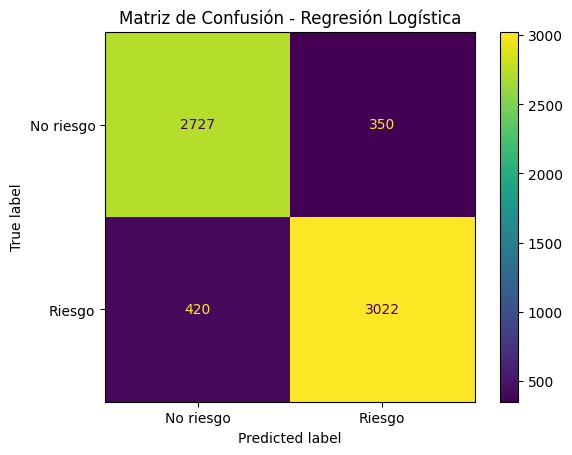

In [88]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


cm = confusion_matrix(
    y_test,
    y_pred
)


disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "No riesgo",
        "Riesgo"
    ]
)


disp.plot()

plt.title(
    "Matriz de Confusión - Regresión Logística"
)

plt.show()

## 6.13 Curva ROC y AUC

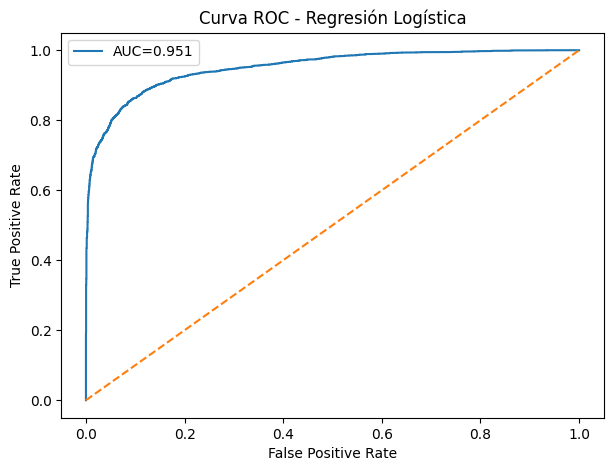

In [89]:
from sklearn.metrics import roc_curve, roc_auc_score


auc = roc_auc_score(
    y_test,
    y_prob
)


fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)


plt.figure(figsize=(7,5))


plt.plot(
    fpr,
    tpr,
    label=f"AUC={auc:.3f}"
)


plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)


plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)


plt.title(
    "Curva ROC - Regresión Logística"
)


plt.legend()

plt.show()

In [90]:
print("AUC:", round(auc,4))

AUC: 0.9506


# Semana 7 — Implementación de modelos avanzados (Random Forest y XGBoost)
Introducción

Con el objetivo de mejorar el desempeño obtenido por el modelo baseline de Regresión Logística, se implementan dos algoritmos avanzados de aprendizaje supervisado ampliamente utilizados en problemas de clasificación:

Random Forest
XGBoost

Ambos modelos pertenecen a la familia de métodos basados en árboles de decisión y poseen la capacidad de capturar relaciones no lineales entre las variables predictoras y la variable objetivo.

La finalidad de esta etapa es comparar el comportamiento de estos modelos sobre el dataset enriquecido construido en la Semana 5 y establecer una línea base para posteriores procesos de optimización de hiperparámetros.

## 7.1 Verificación de los conjuntos de entrenamiento y prueba

In [91]:
print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (26074, 54)
Prueba: (6519, 54)


# Implementación de Random Forest

## 7.2 Construcción del modelo Random Forest

In [92]:
from sklearn.ensemble import RandomForestClassifier

In [93]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [94]:
rf_model.fit(
    X_train,
    y_train
)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## 7.3 Predicciones Random Forest

In [95]:
y_pred_rf = rf_model.predict(X_test)

y_prob_rf = rf_model.predict_proba(X_test)[:,1]

In [96]:
print(y_pred_rf[:10])

[0 1 0 0 0 0 1 1 1 0]


## 7.4 Evaluación de Random Forest

In [97]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [98]:
accuracy_rf = accuracy_score(
    y_test,
    y_pred_rf
)

precision_rf = precision_score(
    y_test,
    y_pred_rf
)

recall_rf = recall_score(
    y_test,
    y_pred_rf
)

f1_rf = f1_score(
    y_test,
    y_pred_rf
)

In [99]:
print("Accuracy :", round(accuracy_rf,4))
print("Precision:", round(precision_rf,4))
print("Recall   :", round(recall_rf,4))
print("F1-score :", round(f1_rf,4))

Accuracy : 0.9425
Precision: 0.9694
Recall   : 0.9201
F1-score : 0.9441


## 7.5 Reporte de clasificación Random Forest

In [100]:
from sklearn.metrics import classification_report

In [101]:
print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

              precision    recall  f1-score   support

           0       0.92      0.97      0.94      3077
           1       0.97      0.92      0.94      3442

    accuracy                           0.94      6519
   macro avg       0.94      0.94      0.94      6519
weighted avg       0.94      0.94      0.94      6519



## 7.6 Matriz de confusión Random Forest

In [102]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

In [103]:
cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

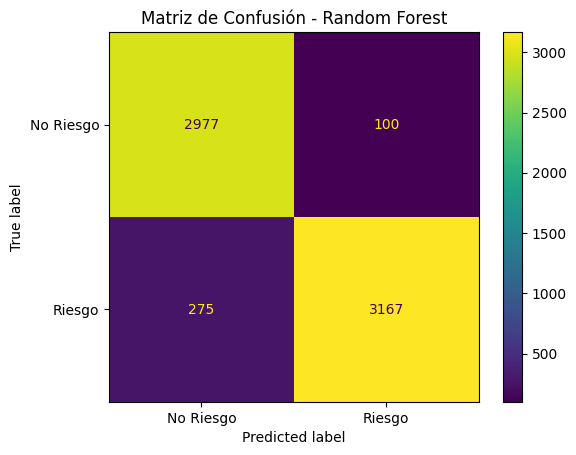

In [104]:
disp_rf = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=[
        "No Riesgo",
        "Riesgo"
    ]
)

disp_rf.plot()

plt.title(
    "Matriz de Confusión - Random Forest"
)

plt.show()

## 7.7 Curva ROC y AUC Random Forest

In [105]:
from sklearn.metrics import (
    roc_curve,
    roc_auc_score
)

In [106]:
auc_rf = roc_auc_score(
    y_test,
    y_prob_rf
)

print(
    "AUC:",
    round(auc_rf,4)
)

AUC: 0.9843


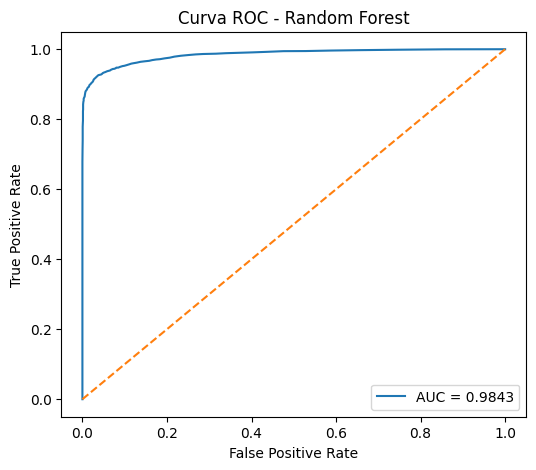

In [107]:
fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    y_prob_rf
)

plt.figure(figsize=(6,5))

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"AUC = {auc_rf:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "Curva ROC - Random Forest"
)

plt.legend()

plt.show()

# Implementación de XGBoost

In [108]:
# Limpieza de nombres de columnas para compatibilidad con XGBoost

X_train.columns = (
    X_train.columns
    .str.replace('[', '', regex=False)
    .str.replace(']', '', regex=False)
    .str.replace('<', '', regex=False)
)


X_test.columns = (
    X_test.columns
    .str.replace('[', '', regex=False)
    .str.replace(']', '', regex=False)
    .str.replace('<', '', regex=False)
)


print("Columnas corregidas correctamente")

Columnas corregidas correctamente


## 7.8 Construcción del modelo XGBoost

In [109]:
from xgboost import XGBClassifier

In [110]:
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

In [111]:
xgb_model.fit(
    X_train,
    y_train
)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


## 7.9 Predicciones XGBoost

In [112]:
y_pred_xgb = xgb_model.predict(
    X_test
)

y_prob_xgb = xgb_model.predict_proba(
    X_test
)[:,1]

In [113]:
print(y_pred_xgb[:10])

[0 1 1 0 0 0 1 1 1 0]


## 7.10 Evaluación de XGBoost

In [114]:
accuracy_xgb = accuracy_score(
    y_test,
    y_pred_xgb
)

precision_xgb = precision_score(
    y_test,
    y_pred_xgb
)

recall_xgb = recall_score(
    y_test,
    y_pred_xgb
)

f1_xgb = f1_score(
    y_test,
    y_pred_xgb
)

In [115]:
print("Accuracy :", round(accuracy_xgb,4))
print("Precision:", round(precision_xgb,4))
print("Recall   :", round(recall_xgb,4))
print("F1-score :", round(f1_xgb,4))

Accuracy : 0.9428
Precision: 0.9674
Recall   : 0.9227
F1-score : 0.9445


## 7.11 Reporte de clasificación XGBoost

In [116]:
print(
    classification_report(
        y_test,
        y_pred_xgb
    )
)

              precision    recall  f1-score   support

           0       0.92      0.97      0.94      3077
           1       0.97      0.92      0.94      3442

    accuracy                           0.94      6519
   macro avg       0.94      0.94      0.94      6519
weighted avg       0.94      0.94      0.94      6519



## 7.12 Matriz de confusión XGBoost

In [117]:
cm_xgb = confusion_matrix(
    y_test,
    y_pred_xgb
)

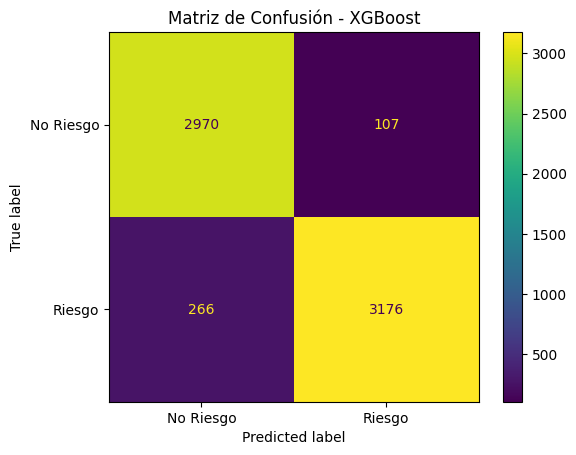

In [118]:
disp_xgb = ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb,
    display_labels=[
        "No Riesgo",
        "Riesgo"
    ]
)

disp_xgb.plot()

plt.title(
    "Matriz de Confusión - XGBoost"
)

plt.show()

## 7.13 Curva ROC y AUC XGBoost

In [119]:
auc_xgb = roc_auc_score(
    y_test,
    y_prob_xgb
)

print(
    "AUC:",
    round(auc_xgb,4)
)

AUC: 0.9857


In [120]:
fpr_xgb, tpr_xgb, _ = roc_curve(
    y_test,
    y_prob_xgb
)

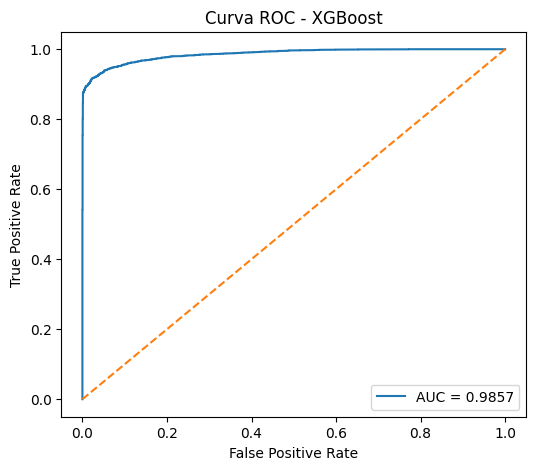

In [121]:
plt.figure(figsize=(6,5))

plt.plot(
    fpr_xgb,
    tpr_xgb,
    label=f"AUC = {auc_xgb:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "Curva ROC - XGBoost"
)

plt.legend()

plt.show()

## 7.14 Comparación de modelos

In [122]:
resultados = pd.DataFrame({

    "Modelo":[
        "Regresión Logística",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy":[
        accuracy,
        accuracy_rf,
        accuracy_xgb
    ],

    "Precision":[
        precision,
        precision_rf,
        precision_xgb
    ],

    "Recall":[
        recall,
        recall_rf,
        recall_xgb
    ],

    "F1-score":[
        f1,
        f1_rf,
        f1_xgb
    ],

    "AUC":[
        auc,
        auc_rf,
        auc_xgb
    ]
})

resultados

,Modelo,Accuracy,Precision,Recall,F1-score,AUC
0,Regresión Logística,0.881884,0.896204,0.877978,0.886997,0.950626
1,Random Forest,0.942476,0.969391,0.920105,0.944105,0.984310
2,XGBoost,0.942783,0.967408,0.922719,0.944535,0.985721


## 7.15 Visualización comparativa

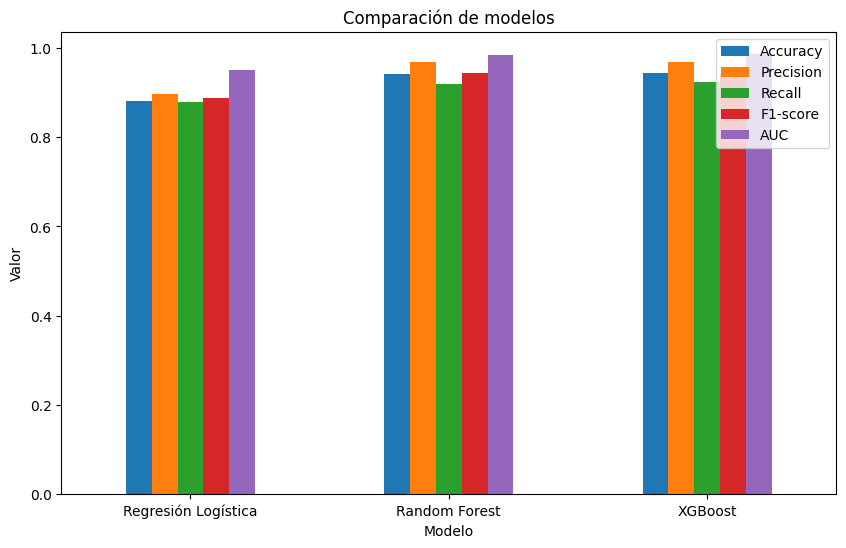

In [123]:
resultados.set_index(
    'Modelo'
)[
    [
        'Accuracy',
        'Precision',
        'Recall',
        'F1-score',
        'AUC'
    ]
].plot(
    kind='bar',
    figsize=(10,6)
)

plt.title(
    'Comparación de modelos'
)

plt.ylabel(
    'Valor'
)

plt.xticks(
    rotation=0
)

plt.show()

## Conclusiones de la Semana 7
Durante esta etapa se implementaron dos modelos avanzados de clasificación basados en árboles de decisión: Random Forest y XGBoost.

Ambos modelos fueron entrenados utilizando el dataset enriquecido generado a partir de las tablas principales de OULAD y posteriormente comparados con el modelo baseline de Regresión Logística desarrollado en la semana anterior.

Los resultados obtenidos permitirán identificar cuál de los enfoques presenta una mayor capacidad predictiva antes de iniciar el proceso de optimización de hiperparámetros mediante técnicas avanzadas como búsqueda aleatoria, búsqueda bayesiana u Optuna, las cuales serán abordadas en la siguiente fase del proyecto.

In [124]:
resultados.sort_values(
    by='F1-score',
    ascending=False
)

,Modelo,Accuracy,Precision,Recall,F1-score,AUC
2,XGBoost,0.942783,0.967408,0.922719,0.944535,0.985721
1,Random Forest,0.942476,0.969391,0.920105,0.944105,0.984310
0,Regresión Logística,0.881884,0.896204,0.877978,0.886997,0.950626


# Semana 8 — Optimización de modelos mediante ajuste de hiperparámetros

En esta etapa se realiza la optimización de los modelos Random Forest y XGBoost mediante ajuste de hiperparámetros utilizando GridSearchCV y validación cruzada estratificada de cinco pliegues.

El objetivo es identificar configuraciones que permitan mejorar el rendimiento predictivo observado en los modelos base implementados durante la Semana 7, especialmente en términos de F1-score y AUC-ROC, métricas fundamentales para la detección de estudiantes en riesgo académico.

La optimización se enfoca en los hiperparámetros más relevantes de cada algoritmo, buscando un equilibrio adecuado entre capacidad predictiva y generalización.

## 8.1 Configuración de validación cruzada
Se utiliza validación cruzada estratificada de cinco pliegues para garantizar que la distribución de clases se mantenga equilibrada durante el proceso de búsqueda de hiperparámetros.

In [125]:
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print(cv)

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


# Optimización de Random Forest

## 8.2 Definición del espacio de búsqueda

In [126]:
param_grid_rf = {

    'n_estimators': [100, 200, 300],

    'max_depth': [
        10,
        15,
        20
    ],

    'min_samples_split': [
        2,
        5
    ],

    'min_samples_leaf': [
        1,
        2
    ],

    'class_weight': [
        None,
        'balanced'
    ]
}

## 8.3 Búsqueda de hiperparámetros

In [127]:
from sklearn.ensemble import RandomForestClassifier

grid_rf = GridSearchCV(

    estimator=RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),

    param_grid=param_grid_rf,

    scoring='f1',

    cv=cv,

    n_jobs=-1,

    verbose=1
)

grid_rf.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'class_weight': [None, 'balanced'], 'max_depth': [10, 15, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], ...}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


## 8.4 Mejores hiperparámetros encontrados

In [128]:
print(
    "Mejores hiperparámetros RF:"
)

print(
    grid_rf.best_params_
)

print(
    "Mejor F1 CV:",
    round(
        grid_rf.best_score_,
        4
    )
)

Mejores hiperparámetros RF:
{'class_weight': None, 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Mejor F1 CV: 0.9449


## 8.5 Evaluación del Random Forest optimizado

In [129]:
rf_best_model = (
    grid_rf.best_estimator_
)

y_pred_rf_opt = (
    rf_best_model.predict(
        X_test
    )
)

y_prob_rf_opt = (
    rf_best_model.predict_proba(
        X_test
    )[:,1]
)

## 8.6 Métricas del Random Forest optimizado

In [130]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

rf_opt_accuracy = accuracy_score(
    y_test,
    y_pred_rf_opt
)

rf_opt_precision = precision_score(
    y_test,
    y_pred_rf_opt
)

rf_opt_recall = recall_score(
    y_test,
    y_pred_rf_opt
)

rf_opt_f1 = f1_score(
    y_test,
    y_pred_rf_opt
)

rf_opt_auc = roc_auc_score(
    y_test,
    y_prob_rf_opt
)

print(
    "Accuracy:",
    round(rf_opt_accuracy,4)
)

print(
    "Precision:",
    round(rf_opt_precision,4)
)

print(
    "Recall:",
    round(rf_opt_recall,4)
)

print(
    "F1:",
    round(rf_opt_f1,4)
)

print(
    "AUC:",
    round(rf_opt_auc,4)
)

Accuracy: 0.9419
Precision: 0.9665
Recall: 0.9218
F1: 0.9436
AUC: 0.9847


## 8.7 Reporte de clasificación Random Forest optimizado

In [131]:
from sklearn.metrics import (
    classification_report
)

print(
    classification_report(
        y_test,
        y_pred_rf_opt
    )
)

              precision    recall  f1-score   support

           0       0.92      0.96      0.94      3077
           1       0.97      0.92      0.94      3442

    accuracy                           0.94      6519
   macro avg       0.94      0.94      0.94      6519
weighted avg       0.94      0.94      0.94      6519



## 8.8 Matriz de confusión Random Forest optimizado

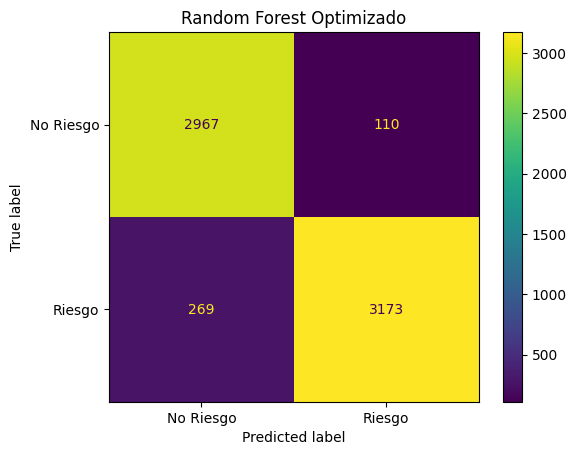

In [132]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

cm_rf_opt = confusion_matrix(
    y_test,
    y_pred_rf_opt
)

disp_rf_opt = (
    ConfusionMatrixDisplay(
        confusion_matrix=cm_rf_opt,
        display_labels=[
            "No Riesgo",
            "Riesgo"
        ]
    )
)

disp_rf_opt.plot()

plt.title(
    "Random Forest Optimizado"
)

plt.show()

# Optimización de XGBoost

## 8.9 Espacio de búsqueda para XGBoost

In [133]:
param_grid_xgb = {

    'n_estimators': [
        100,
        200,
        300
    ],

    'max_depth': [
        4,
        6,
        8
    ],

    'learning_rate': [
        0.01,
        0.05,
        0.1
    ],

    'subsample': [
        0.8,
        1.0
    ],

    'colsample_bytree': [
        0.8,
        1.0
    ]
}

## 8.10 Búsqueda de hiperparámetros

In [134]:
from xgboost import XGBClassifier

grid_xgb = GridSearchCV(

    estimator=XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    ),

    param_grid=param_grid_xgb,

    scoring='f1',

    cv=cv,

    n_jobs=-1,

    verbose=1
)

grid_xgb.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [4, 6, ...], 'n_estimators': [100, 200, ...], ...}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


## 8.11 Mejores hiperparámetros encontrados

In [135]:
print(
    "Mejores hiperparámetros XGBoost:"
)

print(
    grid_xgb.best_params_
)

print(
    "Mejor F1 CV:",
    round(
        grid_xgb.best_score_,
        4
    )
)

Mejores hiperparámetros XGBoost:
{'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 200, 'subsample': 1.0}
Mejor F1 CV: 0.9496


## 8.12 Evaluación del XGBoost optimizado

In [136]:
xgb_best_model = (
    grid_xgb.best_estimator_
)

y_pred_xgb_opt = (
    xgb_best_model.predict(
        X_test
    )
)

y_prob_xgb_opt = (
    xgb_best_model.predict_proba(
        X_test
    )[:,1]
)

## 8.13 Métricas del XGBoost optimizado

In [137]:
xgb_opt_accuracy = accuracy_score(
    y_test,
    y_pred_xgb_opt
)

xgb_opt_precision = precision_score(
    y_test,
    y_pred_xgb_opt
)

xgb_opt_recall = recall_score(
    y_test,
    y_pred_xgb_opt
)

xgb_opt_f1 = f1_score(
    y_test,
    y_pred_xgb_opt
)

xgb_opt_auc = roc_auc_score(
    y_test,
    y_prob_xgb_opt
)

print(
    "Accuracy:",
    round(xgb_opt_accuracy,4)
)

print(
    "Precision:",
    round(xgb_opt_precision,4)
)

print(
    "Recall:",
    round(xgb_opt_recall,4)
)

print(
    "F1:",
    round(xgb_opt_f1,4)
)

print(
    "AUC:",
    round(xgb_opt_auc,4)
)

Accuracy: 0.9472
Precision: 0.974
Recall: 0.9248
F1: 0.9487
AUC: 0.9867


## 8.14 Reporte de clasificación XGBoost optimizado

In [138]:
print(
    classification_report(
        y_test,
        y_pred_xgb_opt
    )
)

              precision    recall  f1-score   support

           0       0.92      0.97      0.95      3077
           1       0.97      0.92      0.95      3442

    accuracy                           0.95      6519
   macro avg       0.95      0.95      0.95      6519
weighted avg       0.95      0.95      0.95      6519



## 8.15 Matriz de confusión XGBoost optimizado

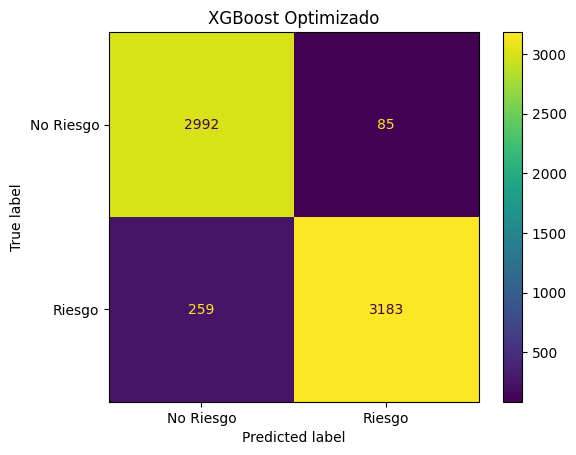

In [139]:
cm_xgb_opt = confusion_matrix(
    y_test,
    y_pred_xgb_opt
)

disp_xgb_opt = (
    ConfusionMatrixDisplay(
        confusion_matrix=cm_xgb_opt,
        display_labels=[
            "No Riesgo",
            "Riesgo"
        ]
    )
)

disp_xgb_opt.plot()

plt.title(
    "XGBoost Optimizado"
)

plt.show()

## 8.16 Comparación final de modelos

In [140]:
comparacion_final = pd.DataFrame({

    "Modelo":[
        "Regresión Logística",
        "Random Forest",
        "XGBoost",
        "Random Forest Optimizado",
        "XGBoost Optimizado"
    ],

    "Accuracy":[
        accuracy,
        accuracy_rf,
        accuracy_xgb,
        rf_opt_accuracy,
        xgb_opt_accuracy
    ],

    "Precision":[
        precision,
        precision_rf,
        precision_xgb,
        rf_opt_precision,
        xgb_opt_precision
    ],

    "Recall":[
        recall,
        recall_rf,
        recall_xgb,
        rf_opt_recall,
        xgb_opt_recall
    ],

    "F1-score":[
        f1,
        f1_rf,
        f1_xgb,
        rf_opt_f1,
        xgb_opt_f1
    ],

    "AUC":[
        auc,
        auc_rf,
        auc_xgb,
        rf_opt_auc,
        xgb_opt_auc
    ]
})

comparacion_final.sort_values(
    by="F1-score",
    ascending=False
)

,Modelo,Accuracy,Precision,Recall,F1-score,AUC
4,XGBoost Optimizado,0.947231,0.973990,0.924753,0.948733,0.986671
2,XGBoost,0.942783,0.967408,0.922719,0.944535,0.985721
1,Random Forest,0.942476,0.969391,0.920105,0.944105,0.984310
3,Random Forest Optimizado,0.941862,0.966494,0.921848,0.943643,0.984692
0,Regresión Logística,0.881884,0.896204,0.877978,0.886997,0.950626


## 8.17 Visualización comparativa final

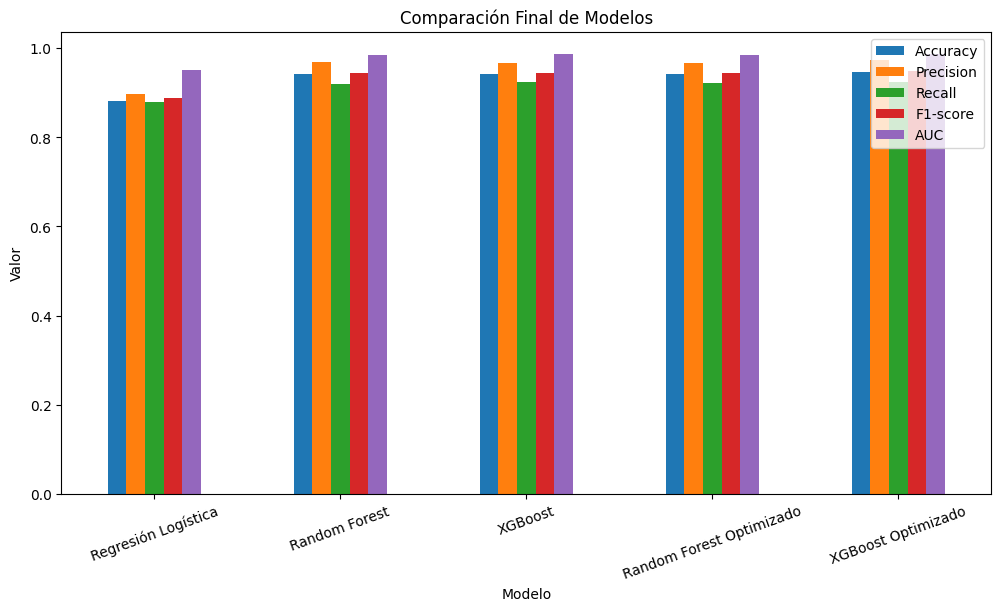

In [141]:
comparacion_final.set_index(
    'Modelo'
)[
    [
        'Accuracy',
        'Precision',
        'Recall',
        'F1-score',
        'AUC'
    ]
].plot(
    kind='bar',
    figsize=(12,6)
)

plt.title(
    'Comparación Final de Modelos'
)

plt.ylabel(
    'Valor'
)

plt.xticks(
    rotation=20
)

plt.show()

## Conclusión de la Semana 8

Durante esta etapa se optimizaron los modelos Random Forest y XGBoost mediante búsqueda sistemática de hiperparámetros utilizando GridSearchCV y validación cruzada estratificada. Los resultados obtenidos permitieron comparar el desempeño de los modelos base frente a sus versiones optimizadas, identificando la configuración con mejor capacidad predictiva para la detección de estudiantes en riesgo académico. Esta evaluación constituye la base para seleccionar el modelo final del proyecto y continuar con las etapas de interpretabilidad y análisis de importancia de variables.

# Semana 9 — Aplicación de técnicas de interpretabilidad (SHAP y LIME)

Aplicar técnicas de Inteligencia Artificial Explicable (XAI) sobre el modelo final XGBoost Optimizado para comprender qué variables influyen en la predicción de estudiantes en riesgo académico y generar explicaciones globales e individuales.

## 9.1 Preparación del modelo para interpretabilidad

In [142]:
print("Modelo seleccionado:")
print(xgb_best_model)

print("\nDimensiones conjunto de prueba:")
print(X_test.shape)

Modelo seleccionado:
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

Dimensiones conjunto de prueba:
(6519, 54)


## 9.2 Interpretabilidad global con SHAP

### Implementación SHAP

In [143]:
%pip install shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [144]:
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(
    xgb_best_model
)

shap_values = explainer.shap_values(
    X_test
)

print("Valores SHAP calculados correctamente")
print("Estudiantes analizados:", shap_values.shape[0])
print("Variables explicativas:", shap_values.shape[1])

c:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Valores SHAP calculados correctamente
Estudiantes analizados: 6519
Variables explicativas: 54


## 9.3 Importancia global de variables

### SHAP Feature Importance

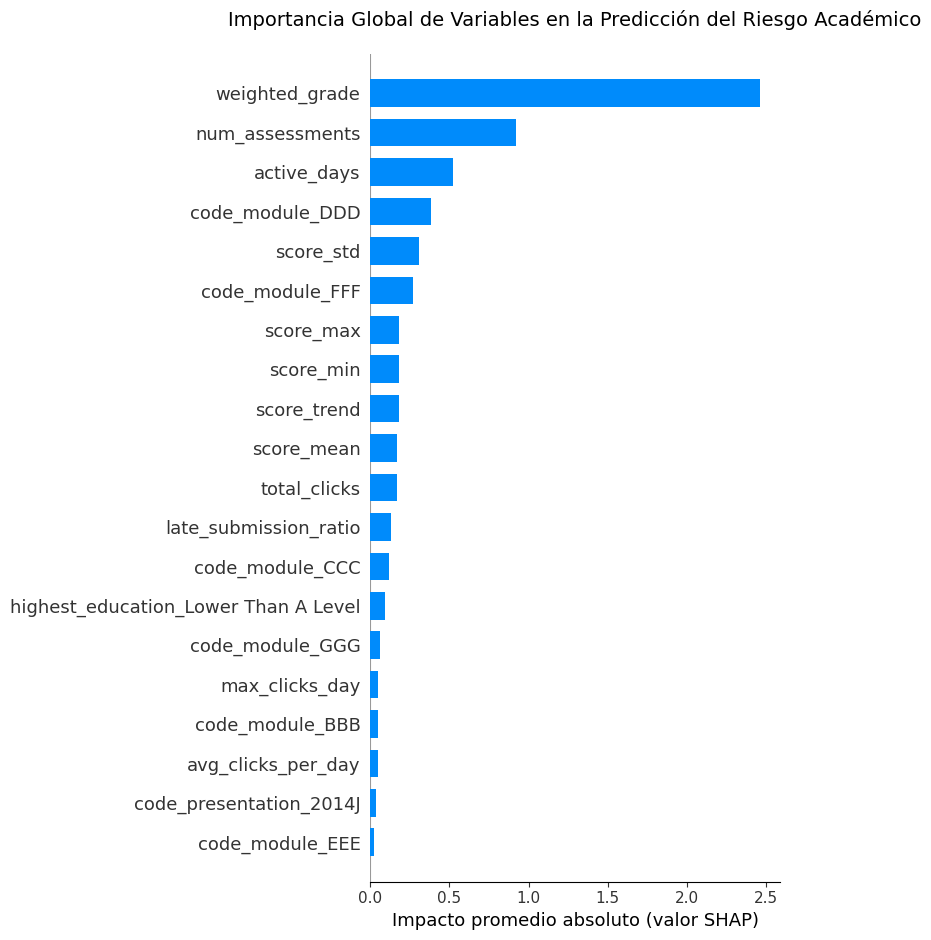

In [145]:
plt.figure(figsize=(10,6))

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    show=False
)

plt.title(
    "Importancia Global de Variables en la Predicción del Riesgo Académico",
    fontsize=14,
    pad=20
)

plt.xlabel(
    "Impacto promedio absoluto (valor SHAP)"
)

plt.tight_layout()
plt.show()

## 9.4 Análisis de impacto de variables

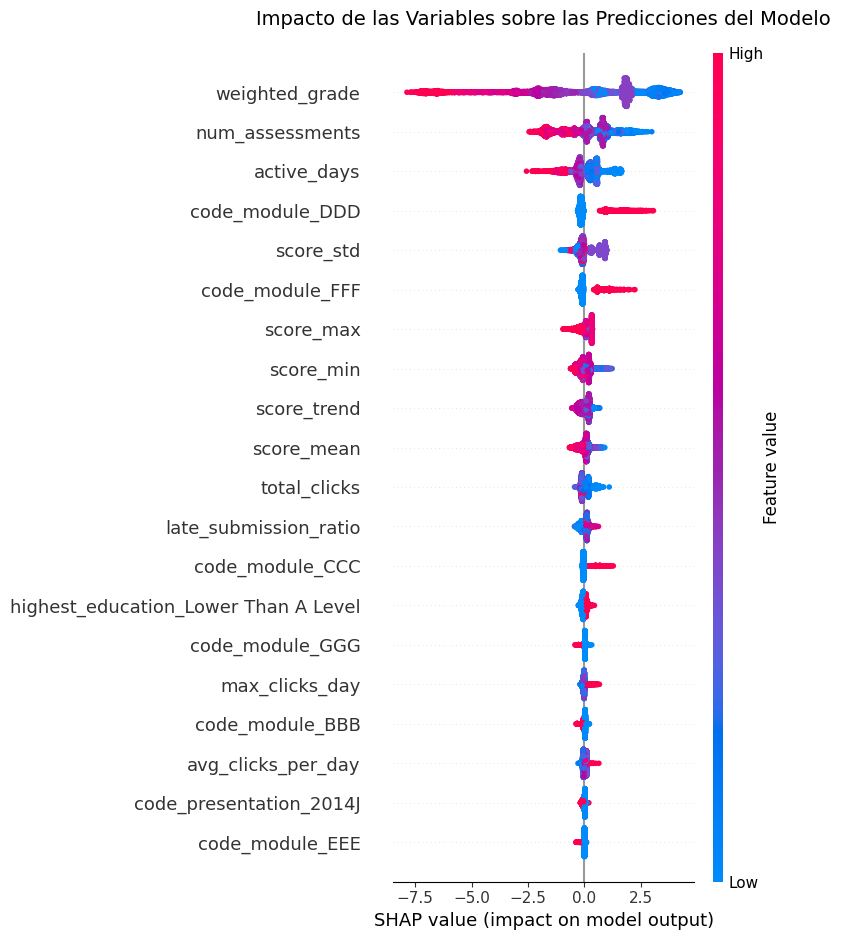

In [146]:
plt.figure(figsize=(10,8))

shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

plt.title(
    "Impacto de las Variables sobre las Predicciones del Modelo",
    fontsize=14,
    pad=20
)

plt.tight_layout()
plt.show()

## 9.5 Ranking de variables SHAP

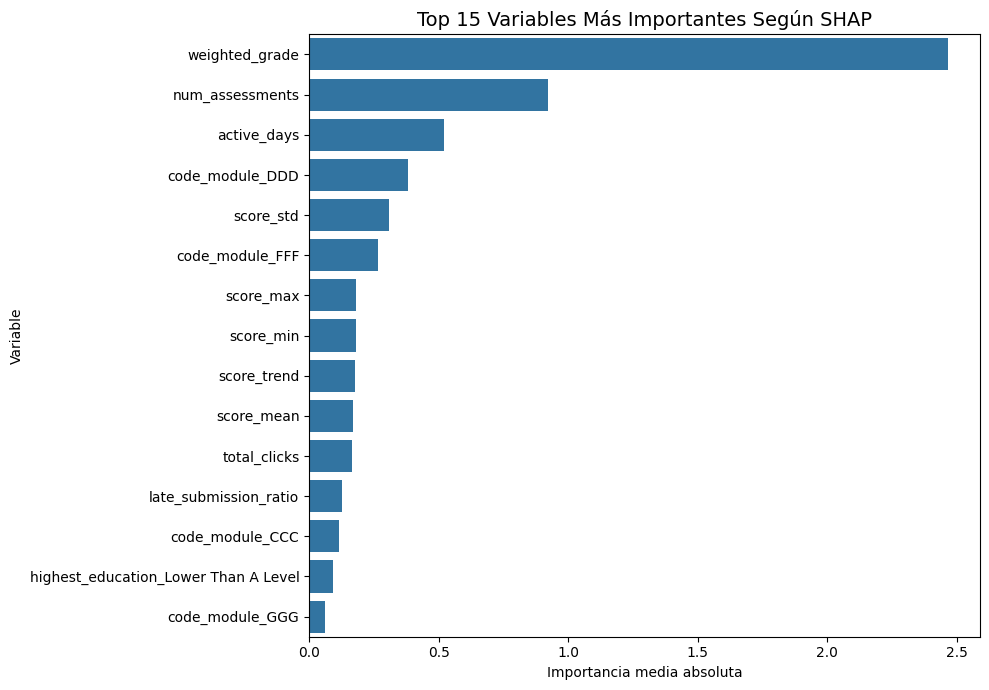

In [147]:
import pandas as pd


importance = pd.DataFrame({
    "Variable": X_test.columns,
    "Importancia": abs(shap_values).mean(axis=0)
})


importance = importance.sort_values(
    "Importancia",
    ascending=False
)


importance.head(15)

import seaborn as sns

top15 = importance.head(15)

plt.figure(figsize=(10,7))

sns.barplot(
    data=top15,
    x="Importancia",
    y="Variable"
)

plt.title(
    "Top 15 Variables Más Importantes Según SHAP",
    fontsize=14
)

plt.xlabel("Importancia media absoluta")
plt.ylabel("Variable")

plt.tight_layout()
plt.show()

## 9.6 Análisis detallado de variables clave

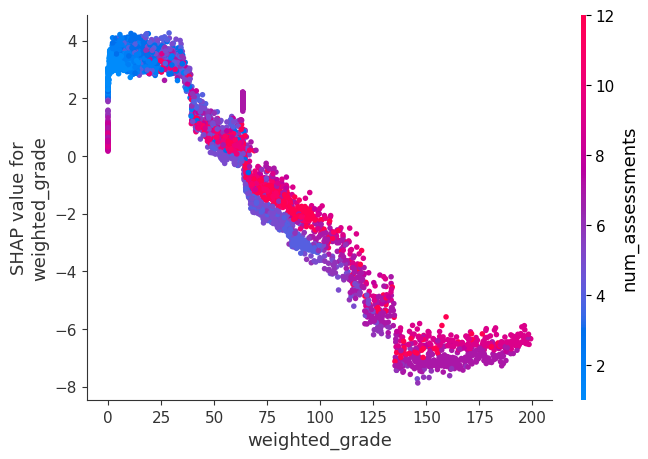

In [148]:
shap.dependence_plot(
    "weighted_grade",
    shap_values,
    X_test
)

# "Efecto de weighted_grade sobre la predicción de riesgo"

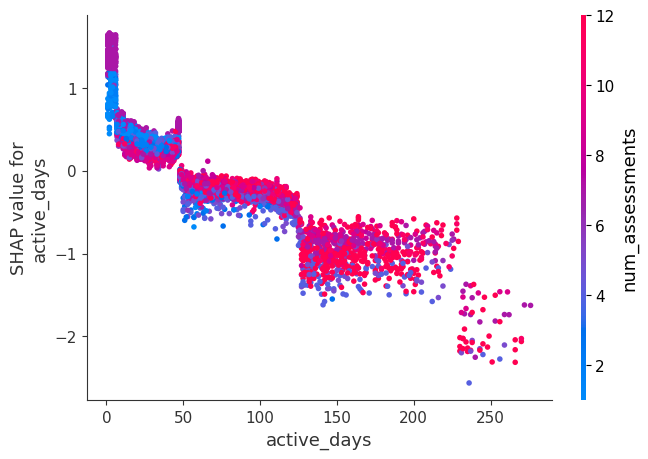

In [149]:
shap.dependence_plot(
    "active_days",
    shap_values,
    X_test
)

# "Efecto de active_days sobre la predicción de riesgo"

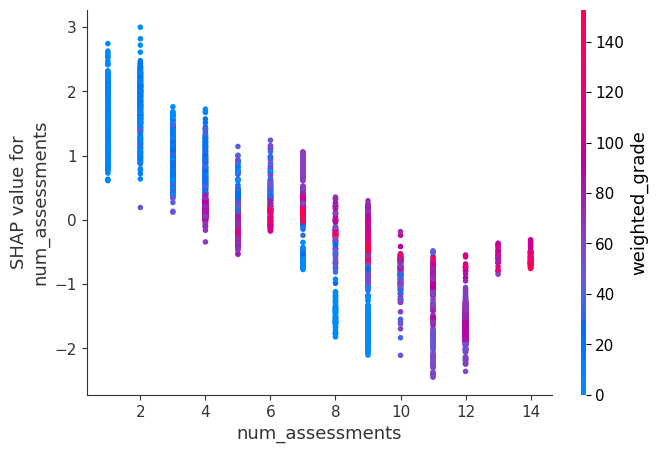

In [150]:
shap.dependence_plot(
    "num_assessments",
    shap_values,
    X_test
)

# "Efecto de num_assessments sobre la predicción de riesgo"

## 9.7 Interpretabilidad local con LIME

In [151]:
%pip install lime

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Configuración de LIME

In [152]:
from lime.lime_tabular import LimeTabularExplainer

explainer_lime = LimeTabularExplainer(
    X_train.values,
    feature_names=X_train.columns,
    class_names=["No Riesgo", "Riesgo"],
    mode="classification"
)

## Caso 1: Estudiante clasificado como Riesgo

### Selección del estudiante

In [153]:
import numpy as np

indice_riesgo = np.where(
    xgb_best_model.predict(X_test) == 1
)[0][0]

indice_riesgo

np.int64(1)

### Probabilidades de predicción

In [154]:
prob_riesgo = xgb_best_model.predict_proba(
    X_test.iloc[[indice_riesgo]]
)[0]

print(f"No Riesgo: {prob_riesgo[0]:.4f}")
print(f"Riesgo: {prob_riesgo[1]:.4f}")

No Riesgo: 0.0035
Riesgo: 0.9965


### Explicación LIME

In [155]:
explicacion_riesgo = explainer_lime.explain_instance(
    X_test.iloc[indice_riesgo].values,
    xgb_best_model.predict_proba,
    num_features=10
)

### Visualización de la explicación

In [180]:
from IPython.display import display, HTML

display(
    HTML(
        explicacion_riesgo.as_html()
    )
)

### Perfil del estudiante

In [157]:
import pandas as pd

perfil_riesgo = pd.DataFrame({
    "Variable": X_test.columns,
    "Valor": X_test.iloc[indice_riesgo]
})

perfil_riesgo.head(20)

,Variable,Valor
num_of_prev_attempts,num_of_prev_attempts,0
studied_credits,studied_credits,30
score_mean,score_mean,76.0
score_max,score_max,92.0
score_min,score_min,60.0
score_std,score_std,12.020815
num_assessments,num_assessments,7.0
weighted_grade,weighted_grade,63.54
score_trend,score_trend,-0.015819
late_submission_ratio,late_submission_ratio,0.2


### Gráfico de contribuciones LIME

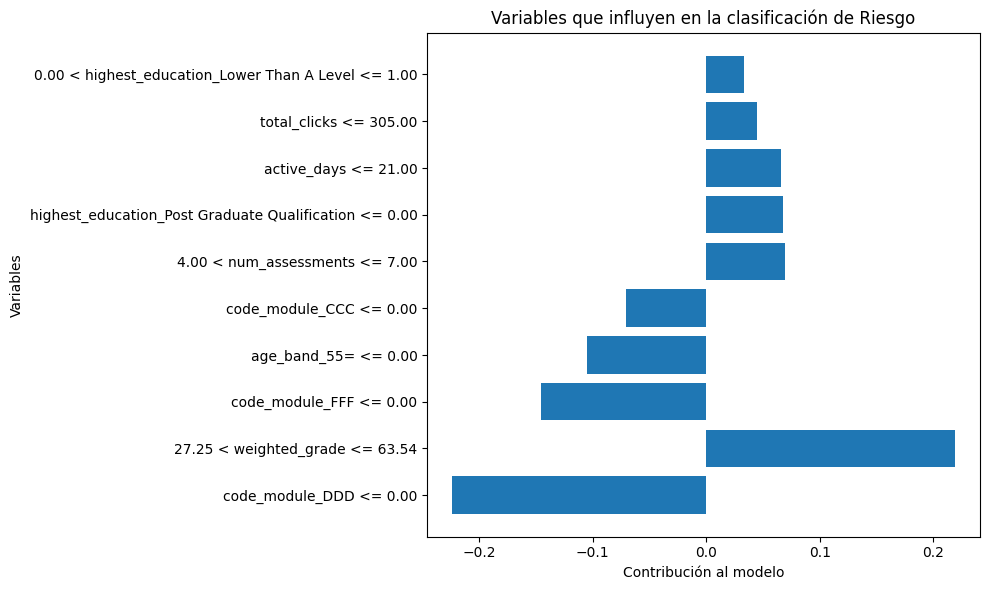

In [158]:
import matplotlib.pyplot as plt

lime_df_riesgo = pd.DataFrame(
    explicacion_riesgo.as_list(),
    columns=["Variable", "Contribucion"]
)

plt.figure(figsize=(10,6))

plt.barh(
    lime_df_riesgo["Variable"],
    lime_df_riesgo["Contribucion"]
)

plt.title(
    "Variables que influyen en la clasificación de Riesgo"
)

plt.xlabel(
    "Contribución al modelo"
)

plt.ylabel(
    "Variables"
)

plt.tight_layout()
plt.show()

## Caso 2: Estudiante clasificado como No Riesgo

### Selección del estudiante

In [159]:
indice_no_riesgo = np.where(
    xgb_best_model.predict(X_test) == 0
)[0][0]

indice_no_riesgo

np.int64(0)

### Probabilidades de predicción

In [160]:
prob_no_riesgo = xgb_best_model.predict_proba(
    X_test.iloc[[indice_no_riesgo]]
)[0]

print(f"No Riesgo: {prob_no_riesgo[0]:.4f}")
print(f"Riesgo: {prob_no_riesgo[1]:.4f}")

No Riesgo: 0.9471
Riesgo: 0.0529


### Explicación LIME

In [161]:
explicacion_no_riesgo = explainer_lime.explain_instance(
    X_test.iloc[indice_no_riesgo].values,
    xgb_best_model.predict_proba,
    num_features=10
)

### Visualización

In [162]:
display(
    HTML(
        explicacion_no_riesgo.as_html()
    )
)

### Perfil del estudiante

In [163]:
perfil_no_riesgo = pd.DataFrame({
    "Variable": X_test.columns,
    "Valor": X_test.iloc[indice_no_riesgo]
})

perfil_no_riesgo.head(20)

,Variable,Valor
num_of_prev_attempts,num_of_prev_attempts,0
studied_credits,studied_credits,60
score_mean,score_mean,87.25
score_max,score_max,98.0
score_min,score_min,72.0
score_std,score_std,8.400487
num_assessments,num_assessments,12.0
weighted_grade,weighted_grade,80.75
score_trend,score_trend,0.063422
late_submission_ratio,late_submission_ratio,0.0


### Gráfico de contribuciones

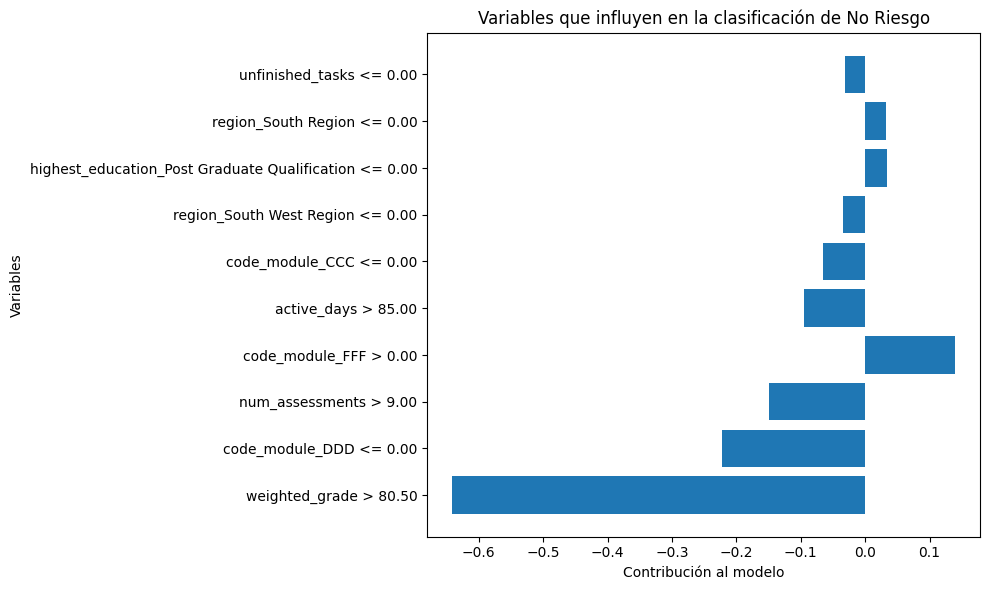

In [164]:
lime_df_no_riesgo = pd.DataFrame(
    explicacion_no_riesgo.as_list(),
    columns=["Variable", "Contribucion"]
)

plt.figure(figsize=(10,6))

plt.barh(
    lime_df_no_riesgo["Variable"],
    lime_df_no_riesgo["Contribucion"]
)

plt.title(
    "Variables que influyen en la clasificación de No Riesgo"
)

plt.xlabel(
    "Contribución al modelo"
)

plt.ylabel(
    "Variables"
)

plt.tight_layout()
plt.show()

## Caso 3: Estudiante con mayor probabilidad de Riesgo

### Identificación del caso extremo

In [165]:
probs = xgb_best_model.predict_proba(X_test)[:,1]

indice_riesgo_extremo = np.argmax(probs)

print(
    "Probabilidad máxima de riesgo:",
    probs[indice_riesgo_extremo]
)

Probabilidad máxima de riesgo: 0.99975663


### Probabilidades

In [166]:
prob_extremo = xgb_best_model.predict_proba(
    X_test.iloc[[indice_riesgo_extremo]]
)[0]

print(f"No Riesgo: {prob_extremo[0]:.4f}")
print(f"Riesgo: {prob_extremo[1]:.4f}")

No Riesgo: 0.0002
Riesgo: 0.9998


### Explicación LIME

In [167]:
explicacion_extrema = explainer_lime.explain_instance(
    X_test.iloc[indice_riesgo_extremo].values,
    xgb_best_model.predict_proba,
    num_features=10
)

### Visualización

In [168]:
display(
    HTML(
        explicacion_extrema.as_html()
    )
)

### Perfil del estudiante

In [181]:
perfil_riesgo_extremo = pd.DataFrame({
    "Variable": X_test.columns,
    "Valor": X_test.iloc[
        indice_riesgo_extremo
    ]
})

perfil_riesgo_extremo.head(20)

,Variable,Valor
num_of_prev_attempts,num_of_prev_attempts,1
studied_credits,studied_credits,60
score_mean,score_mean,76.0
score_max,score_max,92.0
score_min,score_min,60.0
score_std,score_std,12.020815
num_assessments,num_assessments,7.0
weighted_grade,weighted_grade,63.54
score_trend,score_trend,-0.015819
late_submission_ratio,late_submission_ratio,0.2


### Gráfico de contribuciones

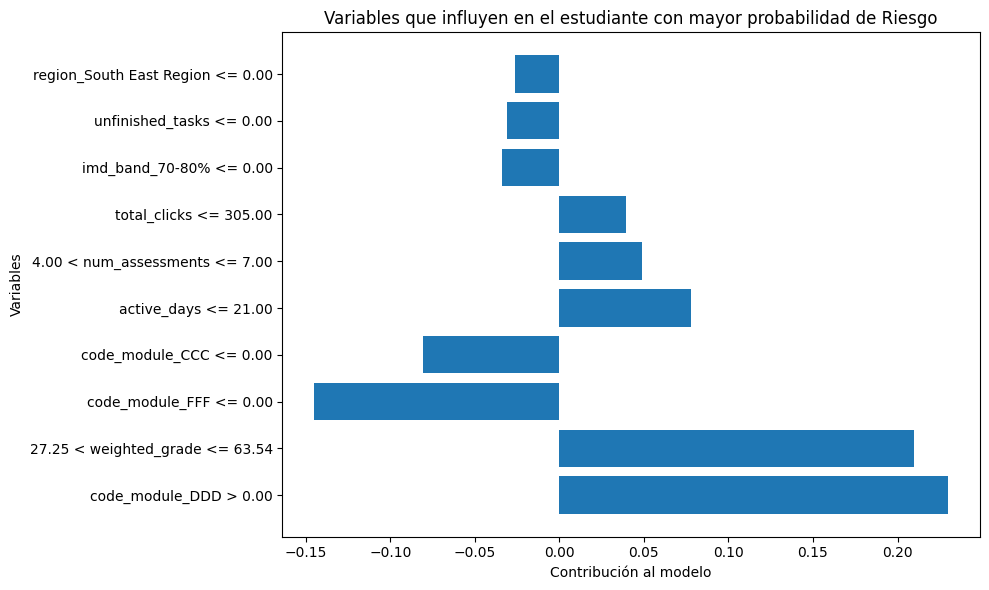

In [169]:
lime_df_extremo = pd.DataFrame(
    explicacion_extrema.as_list(),
    columns=["Variable", "Contribucion"]
)

plt.figure(figsize=(10,6))

plt.barh(
    lime_df_extremo["Variable"],
    lime_df_extremo["Contribucion"]
)

plt.title(
    "Variables que influyen en el estudiante con mayor probabilidad de Riesgo"
)

plt.xlabel(
    "Contribución al modelo"
)

plt.ylabel(
    "Variables"
)

plt.tight_layout()
plt.show()

## Caso 4: Estudiante con mayor probabilidad de No Riesgo

### Identificación del caso extremo

In [170]:
probs_no_riesgo = xgb_best_model.predict_proba(X_test)[:,0]

indice_no_riesgo_extremo = np.argmax(
    probs_no_riesgo
)

print(
    "Probabilidad máxima de No Riesgo:",
    probs_no_riesgo[indice_no_riesgo_extremo]
)

Probabilidad máxima de No Riesgo: 0.99981517


### Probabilidades de predicción

In [171]:
prob_no_riesgo_extremo = xgb_best_model.predict_proba(
    X_test.iloc[[indice_no_riesgo_extremo]]
)[0]

print(
    f"No Riesgo: {prob_no_riesgo_extremo[0]:.4f}"
)

print(
    f"Riesgo: {prob_no_riesgo_extremo[1]:.4f}"
)

No Riesgo: 0.9998
Riesgo: 0.0002


### Explicación LIME

In [172]:
explicacion_no_riesgo_extrema = (
    explainer_lime.explain_instance(
        X_test.iloc[
            indice_no_riesgo_extremo
        ].values,
        xgb_best_model.predict_proba,
        num_features=10
    )
)

### Visualización de la explicación

In [173]:
from IPython.display import display, HTML

display(
    HTML(
        explicacion_no_riesgo_extrema.as_html()
    )
)

### Perfil del estudiante

In [174]:
perfil_no_riesgo_extremo = pd.DataFrame({
    "Variable": X_test.columns,
    "Valor": X_test.iloc[
        indice_no_riesgo_extremo
    ]
})

perfil_no_riesgo_extremo.head(20)

,Variable,Valor
num_of_prev_attempts,num_of_prev_attempts,0
studied_credits,studied_credits,60
score_mean,score_mean,98.285714
score_max,score_max,100.0
score_min,score_min,94.0
score_std,score_std,2.429972
num_assessments,num_assessments,7.0
weighted_grade,weighted_grade,197.9
score_trend,score_trend,-0.003525
late_submission_ratio,late_submission_ratio,0.0


### Gráfico de contribuciones LIME

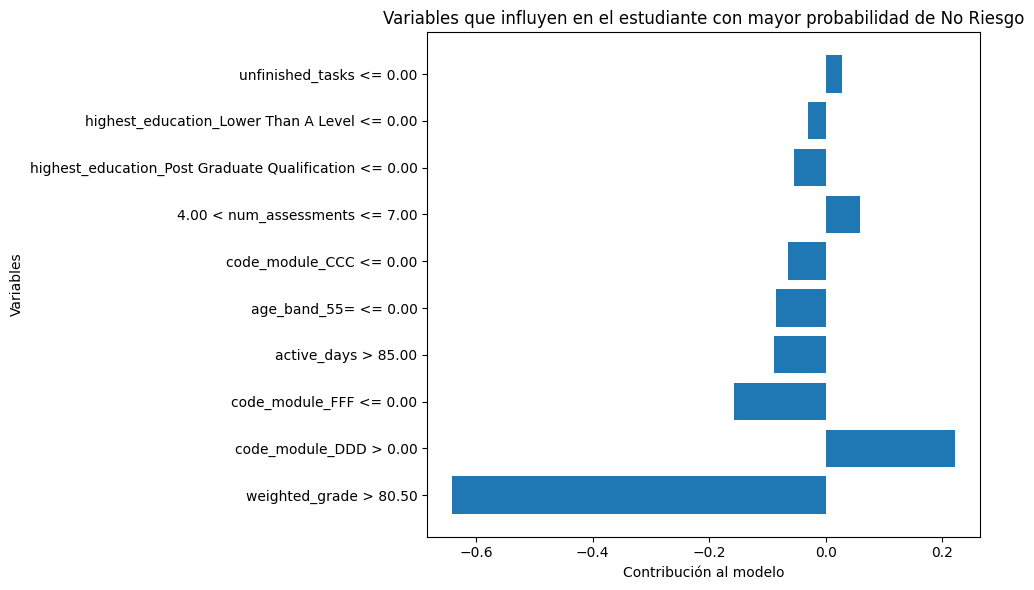

In [175]:
lime_df_no_riesgo_extremo = pd.DataFrame(
    explicacion_no_riesgo_extrema.as_list(),
    columns=[
        "Variable",
        "Contribucion"
    ]
)

plt.figure(figsize=(10,6))

plt.barh(
    lime_df_no_riesgo_extremo["Variable"],
    lime_df_no_riesgo_extremo["Contribucion"]
)

plt.title(
    "Variables que influyen en el estudiante con mayor probabilidad de No Riesgo"
)

plt.xlabel(
    "Contribución al modelo"
)

plt.ylabel(
    "Variables"
)

plt.tight_layout()
plt.show()